# $\color{gray}{\text{7.0 Lecture Note Preparation}}$

```bash
conda create -n net-model python=3.10 -y
conda activate net-model
conda install numpy matplotlib scipy ipykernel ipywidgets jupyter -y
jupyter notebook --no-browser --port=8888
```

- 在[浏览器](http://127.0.0.1:8888)阅读(推荐!)
- [点击](http://127.0.0.1:8888) 并在右上角点击选择 `Trusted`, 并启用插件 `Jupyter Notebook Renderers`, 从而在 VS Code 阅读

# $\color{gray}{\text{7.1 Introduction}}$

## 7.1.1 神经网络的计算潜力

- 网络连接的复杂性: 神经回路中存在广泛的突触连接 [Example] 哺乳动物新皮层(Neocortex) 接收成千上万的突触输入
- 核心计算功能:
  - 坐标变换(Coordinate transformation): 视觉引导运动
  - 选择性放大(Selective amplification): 初级视觉皮层中的简单和复杂细胞模型
  - 积分(Integration): 短期记忆模型
  - 降噪(Noise reduction), 输入选择(Input selection), 增益调节(Gain modulation)
  - 联想记忆(Associative memory)

## 7.1.2 新皮质回路, 以及三种核心连接模式

- 皮层柱(Cortical Columns): 新皮层神经元分布在 6 个垂直的层中, 并形成高度耦合的圆柱结构. 

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/00/Cortical_Columns.jpg/1920px-Cortical_Columns.jpg" width="50%">

- 主要的突触连接类型
  - 前馈连接(Feedforward): 将输入信号从较早阶段区域传递到给定的后续区域
  - 循环连接(Recurrent): 同一阶段/区域内的神经元彼此相连 [Example] 皮层柱内部和柱间
  - 自上而下连接(Top-down): 信号从较晚阶段区域反向传回早期区域 

> 相连区域间, 前馈和自上而下的神经纤维数量通常相当, 即使强度不同. 

## 7.1.3 建模选择

- 脉冲模型(Spiking Models): 刻画脉冲活动. 但是一个模型单元不能替代多个真实神经元的同步放电(否则造成不真实的大规模同步)

- 放电率/发放率模型(Firing-Rate Models)
  - 适用场景: 神经元的不相关放电; 忽略精确脉冲模式
  - 局限性: 无法解释脉冲时序(spike timing)和脉冲相关性(spike correlations)


# $\color{gray}{\text{7.2 Firing-Rate Models}}$

## 7.2.1 从 Spikes 到放电率

> 神经元产生的 Spikes 序列表述为 **神经响应函数** (neural response function) $\begin{aligned}\rho(t) = \sum_{i}A_{i}\delta(t-t_{i})\end{aligned}$

- 核心近似: 使用近似量 **放电率** $r(t)$ 取代了以往的 $\rho(t)$. 也可解读为放电的概率密度, 通过对 $\rho(t)$ 进行系综平均(averaging over trials) $\langle\cdot\rangle$ 得到. 

- 合理性证明: 放电率 $r(t)$ 是否可近似真实 spikes 序列 $\rho(t)$ 在网络中的动力学表现. 
  1. 设依赖网络动力学的物理量 $C$, 若对 $\sigma(\rho) = \langle\rho^{2}\rangle-\langle\rho\rangle^{2}$ 不敏感, 则以 $r(t)$ 替代 $\rho(t)$ 合理. 
  2. 在网络中, 神经元的总输入 $h$ 需要被精确描述. 单个突触的输入方差 $\sigma(h)$ 通常很大. 
    - 不相关输入: 将 $N$ 个不相关突触输入 $h_{j}$ 相加, 则 $\langle h\rangle \propto N$, $\sigma(h) \propto \sqrt{N}$. 使用 $r(t)$ 替代 $\rho(t)$ 是合理的. 
    - 相关输入: Firing-Rate 模型不适用. [Example] 突触前神经元同步放电(synchronous firing)
  3. 突触前 spike 序列输入会被神经元动力学低通滤波, 类似于对输入的平滑. 若建模的突触传递较缓慢, 则 $r(t)$ 近似更准确. 



## 7.2.2 建模步骤

1. 神经元接受到的总突触输入 $h$ 如何依赖突触前输入的放电率 $r$. 

2. 突触后神经元放电率 $r$ 如何依赖总突触输入 $h$. 
   - 总突触输入: 所有突触前动作电位引起突触电导变化, 从而在胞体上产生的总电流 $I_{s}$
   - 假设: 除了动作电位期间, 膜电位始终在略低于阈值水平. 则 $I_{s}$ 接近于胞体测得的突触电流

- $u$: 突触前放电率
- $v$: 突触后放电率

> 考虑多个神经元输入或输出时, 使用矢量形式 $\vec{u}$ 和 $\vec{v}$. 


## 7.2.3 总突触电流(Total Synaptic Current)

<img src=https://files.seeusercontent.com/2026/04/29/uUh8/20260429161426530.png width="50%">

一个神经元接受 $N_{u}$ 个突触 (编号为 $b = \{1,2,\cdots,N_{u}\}$) 输入, 各输入放电率为 $u_{b}$, 或写作 $N_{u}$ 维矢量 $\vec{u}$ 形式. 

$t=0$ 时, $b$ 突触有动作电位, 则 $t = t^{\prime}$ 时该 突触前事件 在 突触后胞体 产生的电流为 $w_{b}K_{s}(t^{\prime})$. 

> - $w_{b}$: $b$ 突触的权重. 
>   - 省去 $b$ 而写作矢量形式, 权重可写作矢量形式 $\vec{w}$
>   - 兴奋性突触 $w_{b} > 0$, 抑制性突触 $w_{b} < 0$
>   - 可令 $w_{b}$ 为变量
> - $K_{s}$: 突触核(synaptic kernel). 

假设单个突触上各 spike 效应独立(线性叠加). 在 $t_{i}$ 时刻 $b$ 突触接收到动作电位, 则 $t$ 时刻的 $b$ 突触的总电流可写作

$$
w_{b}\sum_{t_{i}<t} K_{s}(t - t_{i}) = w_{b} \int_{-\infty}^{t}\mathrm{d}t^{\prime} K_{s}(t-t^{\prime})\rho_{b}(t^{\prime})
$$

> $\begin{aligned}\rho_{b}(t^{\prime}) = \sum_{i} \delta(t^{\prime} - t_{i})\end{aligned}$: 神经响应方程, 表示 $b$ 突触的 spike 序列. 

若突触电流彼此独立, 则所有突触前电流为对 $b$ 求和, 且做替换 $\rho_{b} \to u_{b}$: 

$$
\begin{aligned}
I_{s} &= \sum_{b=1}^{N_{u}} w_{b} \int_{-\infty}^{t}\mathrm{d}t^{\prime}K_{s}(t-t^{\prime})\rho_{b}(t^{\prime})\\
&= \sum_{b=1}^{N_{u}} w_{b} \int_{-\infty}^{t}\mathrm{d}t^{\prime}K_{s}(t-t^{\prime})u_{b}(t^{\prime})
\end{aligned}
$$

突触核 $K_{s}$ 通常选作 $\begin{aligned}\frac{1}{\tau_{r}}e^{-t/\tau_{r}}\end{aligned}$, 对上式 $\begin{aligned}\frac{\mathrm{d}}{\mathrm{d}t}\end{aligned}$ 得到

$$
\begin{aligned}
I_{s} &= \frac{1}{\tau_{s}}e^{-\frac{t}{\tau_{s}}}\sum_{b=1}^{N_{u}}w_{b}\int_{-\infty}^{t}\frac{1}{\tau_{s}} e^{\frac{t^{\prime}}{\tau_{s}}}u_{b}(t^{\prime})\mathrm{d}t^{\prime}\\
\frac{\mathrm{d}I_{s}}{\mathrm{d}t} &= \left[-\frac{1}{\tau_{s}}\left(\frac{1}{\tau_{s}}e^{-\frac{t}{\tau_{s}}}\right)\right]\cdot \left[\sum_{b=1}^{N_{u}}w_{b}\int_{-\infty}^{t}\frac{1}{\tau_{s}} e^{\frac{t^{\prime}}{\tau_{s}}}u_{b}(t^{\prime})\mathrm{d}t^{\prime}\right] + \left[\frac{1}{\tau_{s}}e^{-\frac{t}{\tau_{s}}}\right]\cdot \left[\sum_{b=1}^{N_{u}}w_{b}e^{\frac{t}{\tau_{s}}}u_{b}(t)\right]\\
&= -\frac{1}{\tau_{s}}I_{s} + \frac{1}{\tau_{s}}\sum_{b=1}^{N_{u}}w_{b}u_{b}(t)\\
\Rightarrow \tau_{s}\frac{\mathrm{d}I_{s}}{\mathrm{d}t} &= -I_{s} + \sum_{b=1}^{N_{u}}w_{b}u_{b}(t) = - I_{s} + \vec{w}\cdot\vec{u}(t)
\end{aligned}
$$

> 对于电紧致(electronically compact)树突, $\tau_{s}$ 将接近描述突触电导衰减的时间常数. 

## 7.2.4 The Firing Rate

> 突触后神经元的放电率 $v$ 如何依赖于总突触前输入 $I_{s}$? 

- 稳态: $v = F(I_{s})$
  - $F(\cdot)$ 是稳态放电率函数(steady-state firing rate function)/激活函数. 

  - $F(\cdot)$ 常被取为饱和函数

    - sigmoid 函数 $\begin{aligned}\sigma(x) = \frac{1}{1+e^{-x}}\end{aligned}$. 具有性质 $\sigma^{\prime} = \sigma(1-\sigma)$. 

        <img src=https://cdn.britannica.com/64/264764-050-A2C174FD/graph-of-a-sigmoid-function.jpg width="40%">

    - 阈值线性函数(threshold linear): $ F(I_{s}) = [I_{s}-\gamma]_{+} = \max{(0, I_{s}-\gamma)}$. $\gamma$ 为阈值. 
  - 稳态输出放电率 $v_{\infty}$. 由于 $\begin{aligned}\frac{\mathrm{d}I_{s}}{\mathrm{d}t} = 0\Rightarrow I_{s} = \vec{w}\cdot\vec{u}\end{aligned}$, 则 $v_{\infty} = F(\vec{w}\cdot\vec{u})$. 
- 时间依赖. 
  - I. 延拓为 $v(t) = F(I_{s}(t))$: 放电率瞬时(instantaneously)跟随 $I_{s}$ 变化. 动力学 $\begin{aligned}\tau_{s}\frac{\mathrm{d}I_{s}}{\mathrm{d}t} = - I_{s} + \vec{w}\cdot\vec{u}(t)\end{aligned}$
  - II. 放电率不随总突触输入瞬时变化. 膜电容和电阻具有时间常数, 相当于对 $I_{s}$ 低通滤波. 则 
    $$
    \tau_{r}\frac{\mathrm{d}v}{\mathrm{d}t} = -v + F(I_{s}(t))
    $$
  - 对于 $\tau_{s}$ (控制 `突触前放电率` $u$ $\to$ `突触电流` $I_{s}$) 和 $\tau_{r}$ (控制 `突触电流` $I_{s}$ $\to$ `突触后放电率` $v$), 通常忽略较快的一个而简化模型. 
    - $\tau_{r}\ll \tau_{s}$: II 退化为 I. 
    - $\tau_{s}\ll \tau_{r}$: $\begin{aligned}\frac{\mathrm{d}I_{s}}{\mathrm{d}t}\end{aligned}$ 迅速为 0. 动力学 $\begin{aligned}\tau_{r} \frac{\mathrm{d}v}{\mathrm{d}t} = -v + F(\vec{w}\cdot\vec{u})\end{aligned}$

## 7.2.5 Firing-Rate Dynamics

<img src="https://files.seeusercontent.com/2026/04/29/w1dO/20260429195749349.png" width="60%">



积分-放电 (integrate-and-fire) 神经元. 输入电流 $I(t) = I_{0} + I_{1}\cos{(\omega t)}$ 下的放电率. $\begin{aligned} f = \frac{\omega}{2\pi} = [1, 50, 100]\mathrm{Hz} \end{aligned}$. 直方图是对 spike 进行 binning 得到的, 实线则是 $v(t) = F(I(t))$. 

结论: 若神经元放电足够快, 则膜电位的低通滤波特性不会影响放电率的动力学. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import time as pytime

# ==========================================
# 1. 基础参数设置 
# ==========================================
tau_m = 10.0      # 膜时间常数 (ms) -> 决定了低通滤波的截止频率
E_L = -65.0       # 静息电位 (mV)
V_th = -50.0      # 动作电位阈值 (mV)
V_reset = -65.0   # 重置电位 (mV)
R_m = 1.0         # 膜电阻 (M ohm)

I_1 = 7.0         # 正弦振幅
I_0_high = 23.0   # 左侧：持续放电 (波谷总线电流远高于阈值)
I_0_low = 13.0    # 右侧：部分放电/整流 (波谷时电流不足以诱发动作电位)

sigma_noise = 4.5 # 提升噪声标准差，彻底打破神经元与正弦波的绝对相位锁定

# 【关键修改】减小时间步长，增加 trial 数量以支持微小的高频 bin_size
dt = 0.1          # 全局时间步长缩小为 0.1 ms，大幅提升高频下的数值精度
T = 1000.0        # 总仿真时间 (ms) 保持1000ms以获得充足的统计样本
time = np.arange(0, T, dt)
n_steps = len(time)

n_trials = 2000   # 增加试次，确保在 0.1ms 步长下的统计仍然平滑
f_list = [1.0, 50.0, 100.0]

# ==========================================
# 2. 向量化神经元仿真函数
# ==========================================
def simulate_lif(I_0, f):
    t_sec = time / 1000.0
    I_inj_array = I_0 + I_1 * np.sin(2 * np.pi * f * t_sec)
    
    v = np.full(n_trials, E_L) 
    spike_counts = np.zeros(n_steps)
    v_example = np.zeros(n_steps)
    
    for i in range(n_steps):
        noise = np.random.randn(n_trials) * sigma_noise
        I_tot = I_inj_array[i] + noise
        
        # Euler 法求解 LIF 微分方程
        dv = (E_L - v + R_m * I_tot) / tau_m * dt
        v += dv
        
        spiked = v >= V_th
        spike_counts[i] = np.sum(spiked)
        v[spiked] = V_reset
        
        # 记录第一个 trial 的电压轨迹作为画图示例
        if spiked[0]:
            v_example[i] = -20.0  # 用较高电位(-20mV)示意脉冲，方便图中观测
        else:
            v_example[i] = v[0]
            
    # 计算每个 dt 上的瞬时发放率
    rate_dt = (spike_counts / n_trials) / (dt / 1000.0)
    return v_example, rate_dt, spike_counts

# ==========================================
# 3. 运行仿真并动态绘图 (紧凑版)
# ==========================================
print(f"正在并行模拟 {len(f_list) * 2} 组实验，总计 {n_trials * len(f_list) * 2} 个 Trial...")
print(f"由于 dt={dt}ms, n_trials={n_trials}，预计耗时可能在 5-15 秒左右，请稍候...")
start_time = pytime.time()

# 【排版修改 1】缩小画布尺寸，(12, 8) 或 (10, 7) 都很适合 Notebook 屏幕浏览
fig, axes = plt.subplots(4, 2, figsize=(12, 8))

for row_idx, f in enumerate(f_list):
    v_h, rate_dt_h, counts_h = simulate_lif(I_0_high, f)
    v_l, rate_dt_l, counts_l = simulate_lif(I_0_low, f)
    
    # 动态分配统计 Bin 大小和平滑窗口
    if f == 1.0:
        show_time = 1000.0   
        bin_size = 20.0      
        smooth_ms = 20.0     
    elif f == 50.0:
        show_time = 100.0    
        bin_size = 1.0       
        smooth_ms = 1.0      
    else: 
        show_time = 50.0     
        bin_size = 0.5       
        smooth_ms = 0.5      
        
    steps_per_bin = int(bin_size / dt)
    bin_centers = np.arange(bin_size/2, T, bin_size)

    # ----------------------------------------------------
    # 第 1 行: 电压示意图
    # ----------------------------------------------------
    if f == 1.0:
        axes[0, 0].plot(time, v_h, color='black', lw=0.8)
        # 【排版修改 2】适度缩小字体 (fontsize 14 -> 11/12)
        axes[0, 0].set_title('Continuous Firing (High $I_0$)', fontsize=12, fontweight='bold')
        axes[0, 0].set_ylabel('V (mV)', fontsize=10)
        axes[0, 0].set_xlim(0, show_time)
        axes[0, 0].set_ylim(-75, -15)
        
        axes[0, 1].plot(time, v_l, color='black', lw=0.8)
        axes[0, 1].set_title('Rectified Firing (Low $I_0$)', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlim(0, show_time)
        axes[0, 1].set_ylim(-75, -15)

    # ----------------------------------------------------
    # 第 2, 3, 4 行: PSTH 与平滑率
    # ----------------------------------------------------
    plot_row = row_idx + 1 
    
    psth_h = (counts_h.reshape(-1, steps_per_bin).sum(axis=1) / n_trials) / (bin_size / 1000.0)
    psth_l = (counts_l.reshape(-1, steps_per_bin).sum(axis=1) / n_trials) / (bin_size / 1000.0)
    
    rate_smooth_h = gaussian_filter1d(rate_dt_h, sigma=smooth_ms / dt)
    rate_smooth_l = gaussian_filter1d(rate_dt_l, sigma=smooth_ms / dt)
    
    max_y = max(rate_smooth_h.max(), rate_smooth_l.max()) * 1.3
    if max_y < 10.0: max_y = 10.0  

    # 左侧：连续放电
    axes[plot_row, 0].bar(bin_centers, psth_h, width=bin_size*0.9, color='lightgray', align='center')
    axes[plot_row, 0].plot(time, rate_smooth_h, color='steelblue', lw=2.0) # 线宽稍微调细
    axes[plot_row, 0].set_ylabel(f'Rate (Hz)\n[f = {int(f)} Hz]', fontsize=10, fontweight='bold')
    axes[plot_row, 0].set_xlim(0, show_time)
    axes[plot_row, 0].set_ylim(0, max_y)
    
    # 右侧：带截断整流
    axes[plot_row, 1].bar(bin_centers, psth_l, width=bin_size*0.9, color='lightgray', align='center')
    axes[plot_row, 1].plot(time, rate_smooth_l, color='tomato', lw=2.0)
    axes[plot_row, 1].set_xlim(0, show_time)
    axes[plot_row, 1].set_ylim(0, max_y)

axes[3, 0].set_xlabel('Time (ms)', fontsize=11)
axes[3, 1].set_xlabel('Time (ms)', fontsize=11)

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)
    # 【排版修改 3】调小刻度字体
    ax.tick_params(axis='both', which='major', labelsize=9)
    
# 【排版修改 4】使用 tight_layout 自动收缩边距，代替手动 adjust
plt.tight_layout()
print(f"计算完成，耗时: {pytime.time() - start_time:.2f} 秒。")
plt.show()

> 以上的实线是通过高斯模糊得到的, 不是真实的模型预测. 仅供与图 7.2 的对比. 

两种 Firing-Rate 模型都不能在任意 $f$ 和 $I_{0}$ 下准确预测. 需要引入方程 $G(I,v)$ (实线)进行更准确的预测. 

## 7.2.6 Feedforward and Recurrent Networks

<img src="https://files.seeusercontent.com/2026/04/29/Tl3w/20260429213320089.png" width="50%">

- A: 前馈. 输入 $\vec{u}$, 前馈权重 $\mathbb{W}$, 输出 $\vec{v}$
  - 动力学: $\begin{aligned} \tau_{r} \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\mathbb{W}\vec{u}) \end{aligned}$, 或分量形式 $\begin{aligned}\tau_{r}\frac{\mathrm{d}v_{i}}{\mathrm{d}t} = -v_{i} + F\left(\sum_{j=1}^{N_{u}}W_{ij}u_{j}\right)\end{aligned}$
- B: 递归. 输入 $\vec{u}$, 前馈权重 $\mathbb{W}$, 递归权重 $\mathbb{M}$, 输出 $\vec{v}$. $M_{ij} = M_{ji}$ 未必成立. 
  - 动力学: $\begin{aligned} \tau_{r} \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\mathbb{W}\vec{u} + \mathbb{M}\vec{v}) = -\vec{v} + \vec{F}(\vec{h} + \mathbb{M}\vec{v})\end{aligned}$, 或分量形式 $\begin{aligned}\tau_{r}\frac{\mathrm{d}v_{i}}{\mathrm{d}t} = -v_{i} + F\left(\sum_{j=1}^{N_{u}}W_{ij}u_{j} + \sum_{i^{\prime}=1}^{N_{v}}M_{ii^{\prime}}v_{i^{\prime}}\right)\end{aligned}$
  - Dale's Law: 单个神经元 $i$ 对所有突触 $i^{\prime}$ 要么完全兴奋, 要么完全抑制. 即 $M_{ii^{\prime}}$ 对 $\forall i^{\prime}$ 同号
    - 拆分为兴奋性神经元 (E) 和抑制性神经元 (I), 则
    $$
    \begin{aligned}
    \tau_{E}\frac{\mathrm{d}\vec{v}_{E}}{\mathrm{d}t} &= -\vec{v}_{E} + \vec{F}_{E}(\vec{h}_{E} + \mathbb{M}_{EE}\vec{v}_{E} + \mathbb{M}_{EI}\vec{v}_{I})\\
    \tau_{I}\frac{\mathrm{d}\vec{v}_{I}}{\mathrm{d}t} &= -\vec{v}_{I} + \vec{F}_{I}(\vec{h}_{I} + \mathbb{M}_{IE}\vec{v}_{E} + \mathbb{M}_{II}\vec{v}_{I})
    \end{aligned}
    $$
    - $\mathbb{M}_{EE}$ 和 $\mathbb{M}_{IE}$ 元素 $\geq 0$; $\mathbb{M}_{EI}$ 和 $\mathbb{M}_{II}$ 元素 $\leq 0$.
  - 对称递归矩阵 $M_{ii^{\prime}} = M_{i^{\prime}i}$. 
    - 这违反了 Dale's Law. 兴奋性 $i$ 和抑制性 $i^{\prime}$, 则 $M_{ii^{\prime}} < 0$ 而 $M_{i^{\prime}i} > 0$.
    - 令 $\tau_{I}\to 0$, 则 $\begin{aligned} \tau_{r} \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\mathbb{W}\vec{u}) \end{aligned}$ 成为拆分后方程组的一个特例  $\mathbb{M} = \mathbb{M}_{EE} + \mathbb{M}_{EI}\mathbb{M}_{IE}$. 

## 7.2.7 Continuous Labeled Networks

- 离散标记: 相比于 $i,j$, 使用特征参数标记神经元更好. 
  - [Example] 初级视觉皮层: 神经元具有偏好角度(preferred orientation), 则使用 $\theta_{i}$. 
  - 突触前神经元 $i^{\prime}$ 到突触后神经元 $i$ 的权重为 $W_{ii^{\prime}} = W(\theta_{i},\theta_{i^{\prime}})$. 若只依赖角度差: $W_{ii^{\prime}} = W(\theta_{i}-\theta_{i^{\prime}})$
- 连续标记: 大规模网络中, 偏好参数可覆盖连续取值范围. 
  - $\theta\in[0,2\pi]$. 设覆盖密度 $\rho(\theta) = \mathrm{const.}$
  - 放电率和权重为 $\theta$ 函数: $\vec{u}(\theta)$ 和 $\vec{v}(\theta)$; $\mathbb{W}(\theta,\theta^{\prime})$ 和 $\mathbb{M}(\theta,\theta^{\prime})$
  - 动力学: 
  $$
  \begin{aligned}
  \tau_{r} \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} &= -\vec{v} + \vec{F}(\mathbb{W}\vec{u} + \mathbb{M}\vec{v})\\ \Rightarrow
  \tau_{r} \frac{\mathrm{d}\vec{v}(\theta)}{\mathrm{d}t} &= -\vec{v}(\theta) + \vec{F}\left(\rho_{\theta}\int_{-\pi}^{+\pi}\mathrm{d}\theta^{\prime}\left[\mathbb{W}(\theta,\theta^{\prime})\vec{u}(\theta^{\prime}) + \mathbb{M}(\theta,\theta^{\prime})\vec{v}(\theta^{\prime})\right]\right)
  \end{aligned}
  $$

# $\color{gray}{\text{7.3 Feedforward Networks}}$

## 7.3.1 Neural Coordinate Transformations(神经坐标变换)

Reach 任务中的坐标变换: 注视方向不同 $\to$ 同一物体在视网膜上受刺激位置不同
    
- 角度记号

  <img src="https://files.seeusercontent.com/2026/04/30/0gMw/20260430150704898.png" width="50%">

  - $s$: 刺激的视网膜角坐标 (刺激位置 $\vec{S}$ 与注视方向 $\vec{F}$ 夹角)
  - $g$: 眼球的注视角 (注视方向 $\vec{F}$ 与头朝向 $\hat{n}$ 夹角)
  - $s+g$: 目标相对头朝向的偏转角 (目标位置 $\vec{S}$ 与头朝向 $\hat{n}$ 夹角)
- 猴 前运动皮层对视觉刺激有反应的神经元的调制曲线

  <img src="https://files.seeusercontent.com/2026/04/30/Bg0c/20260430153328111.png" width="55%">

  - A: 固定猴头朝向 $\hat{n}$. 控制猴子注视 "+" 标记(三种, 对应不同曲线), 从而固定注视方向 $\vec{F}$. 另一个物体环绕猴子移动 ($s+g\in (-30^{\circ}, 60^{\circ})$). 
    - 注意到对于不同注视方向 $g$, 在 $s+g$ 上的调制曲线几乎不变
    - 结论: 前运动皮层神经元仅依赖于 $s+g$, 即目标相对头朝向的偏转角, 而非视网膜角坐标 $s$. 
  - B: 猴头朝向 $\hat{n}(\theta)$ 和 $\hat{n}(\theta + 15^{\circ})$. 在 $s$ 上调制曲线发生了 $15^{\circ}$ 的平移. 
    - 结论: 前运动皮层的感受野是基于目标相对头朝向的偏转角 $s+g$. 当 $g^{\prime} = g + \delta\theta$, 则 $s^{\prime} = s - \delta\theta$ 维持调制曲线不变. 
  - C: 前馈模型计算得到的调制曲线. $g = [0^{\circ}, 10^{\circ}, -20^{\circ}]$
    - 结论: 前馈模型预测和 B 中的调制曲线偏移现象一致. 
- 神经元模型: 调制曲线为 $s+g$ 的函数
  - 生物学基础: 顶叶后部皮层(posterior parietal cortex) 7a 区同时依赖于 $s$ 和 $g$. 
  - 增益调节(gaze-dependent gain modulation): 注视方向 $g$ 改变的是 7a 的调制曲线的幅值 (不同于前文的偏移机制)

    <img src="https://files.seeusercontent.com/2026/04/30/aGz0/20260430164409174.png" width="60%">
    
    - A: $s$ 为横轴. 两曲线的 $g$ 不同, 仅仅是改变了幅值而没有改变分布. 
    - B: $r(s,g)$ 三维图. 
      - $\xi$: 偏好的视网膜角坐标
      - $\gamma$: 产生最大增益的一般的注视方向
  - 建模
    - 输出: 运动前区皮层神经元
    - 输入: 7a 区神经元群 (增益调节). 放电率调制曲线: $u_{i} = f_{u}(s-\xi_{i}, g-\gamma_{i})$, 是 $(s-\xi_{i})$ 的高斯曲线 $\times$ $(g-\gamma_{i})$ 的 sigmoid 曲线.
    - 稳态响应: 
      - 输入量 $\begin{aligned}h = \vec{w}\cdot\vec{u} = \sum_{i} w_{i}u_{i} = \sum_{i=1}^{N} w_{i}f_{u}(s-\xi_{i}, g-\gamma_{i})\end{aligned}$
      - 稳态响应(离散): $\begin{aligned}v_{\infty} = F(h) = F \left(\sum_{i=1}^{N} w_{i}f_{u}(s-\xi_{i}, g-\gamma_{i})\right)\end{aligned}$
      - 稳态响应(连续): 将配对的 $(\xi_{i},\gamma_{i})$ 拆分为 $(\xi_{j},\gamma_{k})$, 从而应用 $\begin{aligned}\sum_{j}\Delta\xi \to \int\mathrm{d}\xi\end{aligned}$ 和 $\begin{aligned}\sum_{k}\Delta\gamma\to\int\mathrm{d}\gamma\end{aligned}$: $\begin{aligned}v_{\infty} = F\left[\rho_{\xi}\rho_{\gamma}\iint\mathrm{d}\xi\mathrm{d}\gamma\, w(\xi,\gamma)f_{u}(s-\xi, g-\gamma)\right]\end{aligned}$
      - 以身体为中心($s+g$ 函数). 令 $\begin{aligned}\xi\to \xi - g,\,\gamma\to\gamma + g:\,v_{\infty} = F\left[\rho_{\xi}\rho_{\gamma}\iint\mathrm{d}\xi\mathrm{d}\gamma\,w(\xi-g,\gamma+g)f_{u}(s+g-\xi, -\gamma)\right]\end{aligned}$. 且要求 $w(\xi-g,\gamma+g) = w(\xi, \gamma)$. 见 Chapter 8. 
    - 结论: 增益调节神经元通过乘法结合感觉输入 $s$ 和调制输入 $g$. 

*提示: 推荐使用[网页端](http://127.0.0.1:8888)使用以下代码*


In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --- 1. 定义模型函数 (与之前一致) ---
def f_u(s, xi, g, gamma, sigma=15.0):
    return np.exp(-((s - xi)**2 + (g - gamma)**2) / (2 * sigma**2))

def weight(xi, gamma, sigma_w=20.0):
    return np.exp(-((xi + gamma)**2) / (2 * sigma_w**2))

def v_inf(s, g, xi_grid, gamma_grid):
    d_xi = xi_grid[1] - xi_grid[0]
    d_gamma = gamma_grid[1] - gamma_grid[0]
    XI, GAMMA = np.meshgrid(xi_grid, gamma_grid)
    W = weight(XI, GAMMA)
    U = f_u(s, XI, g, GAMMA)
    return np.sum(W * U) * d_xi * d_gamma

# --- 2. 初始化计算空间 ---
s_values = np.linspace(-60, 60, 100) 
xi_grid = np.linspace(-90, 90, 60)   
gamma_grid = np.linspace(-90, 90, 60) 

# --- 3. 定义绘图包装函数 ---
def plot_coordinate_transform(g):
    """根据传入的注视角度 g，计算并绘制响应曲线"""
    response_curve = [v_inf(s, g, xi_grid, gamma_grid) for s in s_values]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(s_values, response_curve, lw=2, color='royalblue')
    
    # 动态标记峰值位置
    ax.axvline(x=-g, color='red', linestyle='--', alpha=0.8, label=f'Peak ($s = {-g}$)')
    
    ax.set_xlim(-60, 60)
    # 锁定 y 轴范围，防止拖动时画面上下跳动
    ax.set_ylim(0, 1200) 
    ax.set_xlabel('Stimulus Location on Retina $s$ (degrees)')
    ax.set_ylabel('Output Firing Rate $v_\infty$')
    ax.set_title('Coordinate Transformation: Body-centered response')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    
    plt.show()

# --- 4. 使用 interact 激活交互 ---
# 这里会自动生成一个原生的 Jupyter 滑动条，并且完美支持 VS Code
widgets.interact(
    plot_coordinate_transform, 
    g=widgets.FloatSlider(value=0, min=-30, max=30, step=2.0, description='Gaze Angle $g$')
)

# $\color{gray}{\text{7.4 Recurrent Networks}}$

更丰富, 更难分析的动力学

## 7.4.1 Linear Recurrent Networks(线性循环网络)


> Recall: $\begin{aligned}\tau_{r}\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\vec{h} + \mathbb{M}\vec{v})\end{aligned}$

激活函数 $F(x) = x$. 这会引入不真实的负 $\vec{v}$. 动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{h} + \mathbb{M}\vec{v}\end{aligned}$

$\mathbb{M}$ 为对称阵时有分析解. 本征方程 $\begin{aligned}\mathbb{M}\cdot\vec{e}_{\mu} = \lambda_{\mu}\vec{e}_{\mu},\quad \mu = \{1,2\cdots,N_{v}\}\end{aligned}$, 或分量形式 $\begin{aligned}\sum_{j=1}^{N_{v}}M_{ij}e_{\mu}^{j} = \lambda_{\mu} e_{\mu}^{j}\end{aligned}$

$\{\vec{e}_{\mu}\}$ 构成正交基 ($\vec{e}_{\mu}\vec{e}_{\nu} = \delta_{\mu\nu}$), 以该基表达 $\begin{aligned}\vec{v}(t) = \sum_{\mu=1}^{N_{v}}c_{\mu}(t)\vec{e}_{\mu}\end{aligned}$. 代入动力学: 

$$
\begin{aligned}
\tau_{r}\sum_{\mu=1}^{N_{v}}\frac{\mathrm{d}c_{\mu}}{\mathrm{d}t}\vec{e}_{\mu} &= - \sum_{\mu=1}^{N_{v}}(1-\lambda_{\mu})c_{\mu}(t) \vec{e}_{\mu} + \vec{h}\\
(\cdots)\cdot\vec{e}_{\nu}\Rightarrow\tau_{r}\frac{\mathrm{d}c_{\nu}}{\mathrm{d}t} &= - (1-\lambda_{\nu})c_{\nu} + \vec{h}\cdot\vec{e}_{\nu}\\
c_{\nu}(t) &= \frac{\vec{h}\cdot\vec{e}_{\nu}}{1-\lambda_{\nu}}\left[1 - \exp{\left(-\frac{t(1-\lambda_{\nu})}{\tau_{r}}\right)}\right] + c_{\nu}(0)\exp{\left[-\frac{t(1-\lambda_{\nu})}{\tau_{r}}\right]},\quad c_{\nu}(0) = \vec{v}(0)\cdot\vec{e}_{\nu}
\end{aligned}
$$

- $\lambda_{\nu} > 1$: $c_{\nu}\to\infty$, 网络不稳定
- $\lambda_{\nu} < 1$: $\begin{aligned}c_{\nu}\to\frac{\vec{h}\cdot\vec{e}_{\nu}}{1-\lambda_{\nu}}\end{aligned}$. $\vec{h}\cdot\vec{e}_{\nu}$ 是 $\vec{h}$ 在 $\vec{e}_{\nu}$ 方向上的投影
  - $\lambda_{\nu}\in(0,1)$: 稳态是投影被放大了 $\begin{aligned}\frac{1}{1-\lambda_{\nu}}\end{aligned}$

$$
\vec{v}_{\infty} = \sum_{\nu=1}^{N_{v}}\frac{\vec{h}\cdot\vec{e}_{\nu}}{1-\lambda_{\nu}}\vec{e}_{\nu}
$$

### 7.4.1.1 Selective Amplification(选择性放大)

- 若 $\begin{aligned}\lambda_{1} = \lim_{\epsilon\to 0}1 - \epsilon\gg \lambda_{i} (i\neq 1)\end{aligned}$, 则 $|c_{1}|\gg |c_{i}|(i\neq 1)$, 则稳态 $\begin{aligned}\vec{v}_{\infty}\approx \frac{(\vec{h}\cdot\vec{e}_{1})}{1-\lambda_{1}}\vec{e}_{1}\end{aligned}$. 

  - 简并(degeneracy): 若 $\begin{aligned}\lambda_{1} = \lambda_{2} = \lim_{\epsilon\to 0}1 - \epsilon\gg \lambda_{i} (i\neq 1)\end{aligned}$, 稳态 $\begin{aligned}\vec{v}_{\infty}\approx \frac{(\vec{h}\cdot\vec{e}_{1})\vec{e}_{1} + (\vec{h}\cdot\vec{e}_{2})\vec{e}_{2}}{1-\lambda_{1}}\end{aligned}$. 

- 结论: 输入被编码至 $\lambda_{i}\sim 1$ 的子空间(维数取决于简并度). 

### 7.4.1.2 Input Integration(输入积分)

- 若 $\lambda_{1} = 1 > \lambda_{i} (i\neq 1)$, 动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}c_{1}}{\mathrm{d}t} = \vec{h}\cdot\vec{e}_{1}\end{aligned}$, 解 $\begin{aligned}c_{1}(t) = c_{1}(0) + \frac{1}{\tau_{r}}\int_{0}^{t}\mathrm{d}t^{\prime}\vec{h}(t^{\prime})\cdot\vec{e}_{1}\end{aligned}$

  - $\vec{h}(t) = \vec{h}(0)$, 则 $c_{1}\propto t\to\infty$. 
  - $\begin{aligned}\vec{h}(t) = \begin{cases} g(t)\neq 0, t\in (0,t_{0})\\ 0, t\in(t_{0},\infty) \end{cases}\end{aligned}$. 
    - $\nu\neq 1$: $\lambda_{\nu} < 1$, $c_{\nu}\to 0$. 
    - 设 $c_{1}(0)=0$, 动力学: $\begin{aligned}\vec{v}(t)\approx \frac{\vec{e}_{1}}{\tau_{r}}\int_{0}^{t}\mathrm{d}t^{\prime}\vec{h}(t^{\prime})\cdot\vec{e}_{1}\end{aligned}$
    - 即使撤去输入 $\vec{h}(t) = 0\,[t\in(t_{0},\infty)]$, 网络表现出持续活动(sustained activity), 即 "记忆". 
- [Example] 脊椎动物眼球位置维持
  
    <img src="https://files.seeusercontent.com/2026/05/04/X2nw/20260504160234935.png" width="50%">
  
  - integrator neurons(内侧前庭核, 舌下前核): 放电率近似正比于眼球方向角
  - burst neurons: 图中出现两次扫视(saccadic), 分别驱动眼球相反方向移动
  - integrator neurons 接收 burst neurons(ON/OFF) 信号并对其积分, 无输入时保持恒定持续活动(persistent activity)
  - 结论: 线性循环网络在 $\mathbb{M}$ 主特征值为 1 时表现出积分能力

### 7.4.1.3 Continuous Linear Recurrent Networks(连续线性循环网络)

recall: 连续形式网络动力学 $\begin{aligned}\tau_{r}\frac{\mathrm{d}v(\theta)}{\mathrm{d}t} = - v(\theta) + F\left[\rho_{\theta}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}W(\theta,\theta^{\prime})u(\theta^{\prime}) + M(\theta,\theta^{\prime})v(\theta^{\prime})\right]\end{aligned}$, 线性 $F(x) = x$ 得到

$\begin{aligned}\tau_{r}\frac{\mathrm{d}v(\theta)}{\mathrm{d}t} = - v(\theta) + h(\theta) + \rho_{\theta}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}M(\theta-\theta^{\prime})v(\theta^{\prime})\end{aligned}$

- $h$, $M$, $v$ 均为 $T=2\pi$ 的周期函数
- $M$ 通过 $\theta-\theta^{\prime}$ 具有平移/旋转不变性, 并且设为偶函数 $M(\theta-\theta^{\prime}) = M(\theta^{\prime}-\theta)$

类比于离散形式的本征方程 $\begin{aligned}\sum_{j=1}^{N}M_{ij}e_{\mu}^{j} = \lambda_{\mu}e_{\mu}^{i}\end{aligned}$, 应用替换 $\begin{aligned}e_{\mu}^{i}\to e_{\mu}(\theta),\,\sum_{j=1}^{N_{v}}M_{ij}v_{j}\to\int_{-\pi}^{\pi}\rho_{\theta}\mathrm{d}\theta^{\prime}M(\theta,\theta^{\prime})v(\theta^{\prime})\end{aligned}$, 连续形式本征方程为

$$
\rho_{\theta} \int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}\,M(\theta-\theta^{\prime})e_{\mu}(\theta^{\prime}) = \lambda_{\mu}e_{\mu}(\theta)
$$

- 平移/旋转不变性($\theta-\theta^{\prime}$): 本征函数为复指数/正余弦函数
  - 猜测解 $e_{\mu}(\theta) = e^{i\mu\theta}\,(\mu\in\mathbb{Z})$, 代入左边有 $\begin{aligned}\rho\int_{-\pi}^{\pi}M(\theta-\theta^{\prime})e^{i\mu\theta^{\prime}}\mathrm{d}\theta^{\prime} = \rho\int_{-\pi}^{\pi}M(z)e^{i\mu(\theta-z)}\mathrm{d}z = e^{i\mu\theta}\left(\rho\int_{-\pi}^{\pi}M(z)e^{-i\mu z}\mathrm{d}z\right) = e^{i\mu\theta}\lambda_{\mu}\end{aligned}$. 
- 归一化要求: $\begin{aligned}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}\,\rho_{\theta}[e_{\mu}(\theta^{\prime})]^{2} = 1\end{aligned}$, 解得 $\begin{aligned}e_{0}(\theta) = \frac{1}{\sqrt{2\pi\rho_{\theta}}}\end{aligned}$, $\begin{aligned}e_{\mu}(\theta) = \frac{\sin{(\mu\theta)}}{\sqrt{\pi\rho_{\theta}}}\end{aligned}$ 和 $\begin{aligned}e_{\mu}(\theta) = \frac{\cos{(\mu\theta)}}{\sqrt{\pi\rho_{\theta}}},\,(\mu\neq 0)\end{aligned}$
- 特征值 $\lambda_{\mu}$ 是 $M$ 的 Fourier 变换: $\begin{aligned}\lambda_{\mu} = \rho_{\theta}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}M(\theta^{\prime})\cos{(\mu\theta^{\prime})}\end{aligned}$
- 根据稳态公式 $\begin{aligned}\vec{v}_{\infty} = \sum_{\nu=1}^{N_{\nu}}\frac{\vec{h}\cdot\vec{e}_{\nu}}{1-\lambda_{\nu}}\vec{e}_{\nu}\end{aligned}$, 类比得到

    $$
    v_{\infty}(\theta) = \frac{1}{1-\lambda_{0}}\int_{-\pi}^{\pi}\frac{\mathrm{d}\theta^{\prime}}{2\pi}h(\theta^{\prime}) 
    + \sum_{\mu=1}^{\infty}\frac{\cos{(\mu\theta)}}{1-\lambda_{\mu}}\int_{-\pi}^{\pi}\frac{\mathrm{d}\theta^{\prime}}{\pi}h(\theta^{\prime})\cos{(\mu\theta^{\prime})} 
    + \sum_{\mu=1}^{\infty}\frac{\sin{(\mu\theta)}}{1-\lambda_{\mu}}\int_{-\pi}^{\pi}\frac{\mathrm{d}\theta^{\prime}}{\pi}h(\theta^{\prime})\sin{(\mu\theta^{\prime})} 
    $$

  - 某 $\lambda_{\mu}\approx 1$ 时, $\begin{aligned}\frac{1}{1-\lambda_{\mu}}\end{aligned}$ 会使该项的贡献无限放大, 其余成分则被抑制; 无论 $h(\theta)$ 成分如何, $\mu=1$ 都会使最终网络活动呈现余弦调制曲线. 
  - [Example] 设定 $\begin{aligned}M(\theta-\theta^{\prime}) = \frac{\lambda_{1}}{\pi\rho_{\theta}}\cos{(\theta-\theta^{\prime})},\,\lambda_{1} = 0.9\end{aligned}$

     <img src="https://files.seeusercontent.com/2026/05/04/3Sfn/20260504195548236.png" width="50%">

    - $\mu=1$ 成分被放大了 $\begin{aligned}\frac{1}{1-\lambda_{1}} = 10\end{aligned}$ 倍, 其余则是 $\begin{aligned}\frac{1}{1-0} = 1\end{aligned}$ 倍. 这相当于信噪比的提升. 

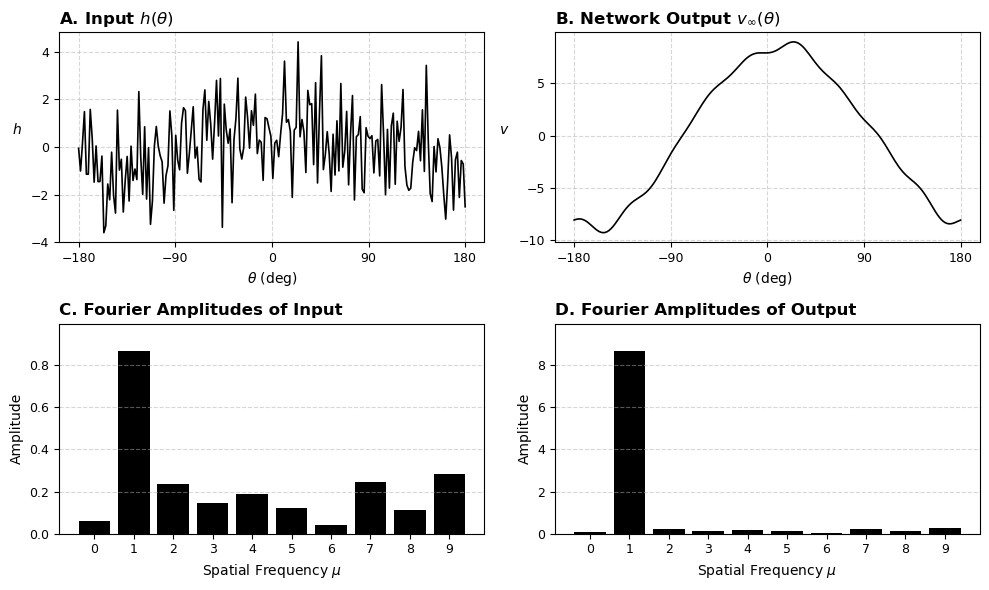

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1-4. 数据生成与计算部分保持不变
# ==========================================
theta = np.linspace(-180, 180, 200) 
theta_rad = np.radians(theta)       
np.random.seed(42) 
base_cosine = 0.8 * np.cos(theta_rad) 
noise = 1.5 * np.random.randn(200)
h_input = base_cosine + noise

lambda_1 = 0.9
gain_mu1 = 1 / (1 - lambda_1)  
gain_other = 1.0               

mu_values = np.arange(10)
h_amplitudes = np.zeros(10)
v_amplitudes = np.zeros(10)
v_inf = np.zeros_like(theta_rad)

for mu in mu_values:
    if mu == 0:
        h_cos_int = np.trapezoid(h_input, theta_rad) / (2 * np.pi)
        h_sin_int = 0.0
    else:
        h_cos_int = np.trapezoid(h_input * np.cos(mu * theta_rad), theta_rad) / np.pi
        h_sin_int = np.trapezoid(h_input * np.sin(mu * theta_rad), theta_rad) / np.pi
    
    h_amplitudes[mu] = np.sqrt(h_cos_int**2 + h_sin_int**2)
    current_gain = gain_mu1 if mu == 1 else gain_other
    v_amplitudes[mu] = h_amplitudes[mu] * current_gain
    
    if mu == 0:
        v_inf += current_gain * h_cos_int
    else:
        v_inf += current_gain * (h_cos_int * np.cos(mu * theta_rad) + h_sin_int * np.sin(mu * theta_rad))

# ==========================================
# 5. 调整后的绘图设置 (更适合 Notebook)
# ==========================================
# 减小 figsize：例如 (10, 6) 或者 (8, 6)
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# 统一调整字体大小
title_fs = 12
label_fs = 10
tick_fs = 9

# Panel A
axs[0, 0].plot(theta, h_input, color='black', linewidth=1.2)
axs[0, 0].set_title('A. Input $h(\\theta)$', loc='left', fontsize=title_fs, fontweight='bold')
axs[0, 0].set_ylabel('$h$', fontsize=label_fs, rotation=0, labelpad=10)
axs[0, 0].set_xlabel('$\\theta$ (deg)', fontsize=label_fs)
axs[0, 0].set_xticks([-180, -90, 0, 90, 180])
axs[0, 0].tick_params(labelsize=tick_fs)
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# Panel B
axs[0, 1].plot(theta, v_inf, color='black', linewidth=1.2)
axs[0, 1].set_title('B. Network Output $v_\\infty(\\theta)$', loc='left', fontsize=title_fs, fontweight='bold')
axs[0, 1].set_ylabel('$v$', fontsize=label_fs, rotation=0, labelpad=10)
axs[0, 1].set_xlabel('$\\theta$ (deg)', fontsize=label_fs)
axs[0, 1].set_xticks([-180, -90, 0, 90, 180])
axs[0, 1].tick_params(labelsize=tick_fs)
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

max_h_amp = np.max(h_amplitudes) * 1.15
max_v_amp = np.max(v_amplitudes) * 1.15

# Panel C
axs[1, 0].bar(mu_values, h_amplitudes, color='black', width=0.8)
axs[1, 0].set_title('C. Fourier Amplitudes of Input', loc='left', fontsize=title_fs, fontweight='bold')
axs[1, 0].set_ylabel('Amplitude', fontsize=label_fs)
axs[1, 0].set_xlabel('Spatial Frequency $\\mu$', fontsize=label_fs)
axs[1, 0].set_xticks(mu_values)
axs[1, 0].set_ylim(0, max_h_amp)
axs[1, 0].tick_params(labelsize=tick_fs)
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# Panel D
axs[1, 1].bar(mu_values, v_amplitudes, color='black', width=0.8)
axs[1, 1].set_title('D. Fourier Amplitudes of Output', loc='left', fontsize=title_fs, fontweight='bold')
axs[1, 1].set_ylabel('Amplitude', fontsize=label_fs)
axs[1, 1].set_xlabel('Spatial Frequency $\\mu$', fontsize=label_fs)
axs[1, 1].set_xticks(mu_values)
axs[1, 1].set_ylim(0, max_v_amp)
axs[1, 1].tick_params(labelsize=tick_fs)
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

# 调整子图间距
plt.tight_layout()
plt.show()

## 7.4.2 Nonlinear Recurrent Networks(非线性循环网络)

- 循环权重: 仍为 $\begin{aligned}M(\theta-\theta^{\prime}) = \frac{\lambda_{1}}{\pi\rho_{\theta}}\cos{(\theta-\theta^{\prime})}\end{aligned}$ 
- 激活函数: 阈值线性函数: $\vec{F}(\vec{h} + \mathbb{M}\vec{r}) = [\vec{h} + \mathbb{M}\vec{r} - \vec{\gamma}]_{+} = \max{(\vec{0}, \vec{h} + \mathbb{M}\vec{r} - \vec{\gamma})}$. 
  - 阈值 $\vec{\gamma}$ 通常选为 $\vec{0}$
- (连续)动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}v(\theta)}{\mathrm{d}t} = - v(\theta) + \left[h(\theta) + \frac{\lambda_{1}}{\pi}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}\cos{(\theta-\theta^{\prime})}v(\theta^{\prime})\right]_{+}\end{aligned}$

### 7.4.2.1 Nonlinear Amplification(非线性放大)

引入阈值函数后, 不需要线性网络的严格条件($\lambda < 1$), 也能消除噪声

<img src="https://files.seeusercontent.com/2026/05/04/7dwV/20260504203418562.png" width="55%">


- $\lambda_{1} = 1.9$: 具有非 0 响应的神经元相对更少(因为阈值)
- 整流 $[\cdot]_{+}$ 的直流和倍频效应: $\mu=0,1,2,4,6,8\cdots$ 都被放大了. 因为 $[\cos{(\theta)}]_{+}$ 不再是纯粹的 $\mu=1$ 波, 将会泄露出其余频率的分量:
  - $\mu=0$(DC 直流): $\begin{aligned}a_{0} = \frac{1}{2\pi}\int_{-\pi/2}^{\pi/2}\cos{(\theta^{\prime})}\mathrm{d}\theta^{\prime} = \frac{1}{\pi}\end{aligned}$
  - $\mu=1$(Fundamental 基频): $\begin{aligned}a_{1} = \frac{1}{\pi}\int_{-\pi/2}^{\pi/2}\cos^{2}{(\theta^{\prime})}\mathrm{d}\theta^{\prime} = \frac{1}{2}\end{aligned}$
  - $\mu=2$(Second Harmonic 二次谐波): $\begin{aligned}a_{2} = \frac{1}{\pi}\int_{-\pi/2}^{\pi/2}\cos{(\theta^{\prime})}\cos{(2\theta^{\prime})}\mathrm{d}\theta^{\prime} = \frac{2}{3\pi}\end{aligned}$
- 更一般的数学推导. 
  - 设 $v(\theta) = [A\cos{(\theta)}- T]_{+}$, 则存在临界 $\theta_{c}$ 使得 $\begin{aligned}\cos{(\theta_{c})} = \frac{T}{A}\end{aligned}$. 即 $\theta\in (-\theta_{c},\theta_{c})$ 神经元放电. 
  - Fourier 级数 $\begin{aligned}v(\theta) = a_{0} + \sum_{\mu=1}^{\infty}a_{\mu}\cos{(\mu\theta)}\end{aligned}$ 展开: $\begin{aligned}a_{\mu} = \frac{1}{\pi}\int_{-\theta_{c}}^{\theta_{c}}[A\cos{(\theta^{\prime})}-T]\cos{(\mu\theta^{\prime})}\mathrm{d}\theta^{\prime} = \frac{A}{\pi}\int_{-\theta_{c}}^{\theta_{c}}[\cos{(\theta^{\prime})}-\cos{\theta_{c}}]\cos{(\mu\theta^{\prime})}\mathrm{d}\theta^{\prime}\end{aligned}$
  - 和差化积解得 $\begin{aligned}a_{\mu} = \frac{A}{\pi}\left\{\frac{\sin{[(\mu-1)\theta_{c}]}}{\mu(\mu-1)} - \frac{\sin{[(\mu+1)\theta_{c}]}}{\mu(\mu+1)}\right\}\end{aligned}$. 
    - $\mu=2k-1$: 振幅为 0
    - $\begin{aligned}\mu=2k:\, a_{2k} = \frac{A}{\pi}\frac{2(-1)^{k+1}}{4k^{2}-1}\end{aligned}$, 从而解释偶次谐波的放大逐渐减少. 

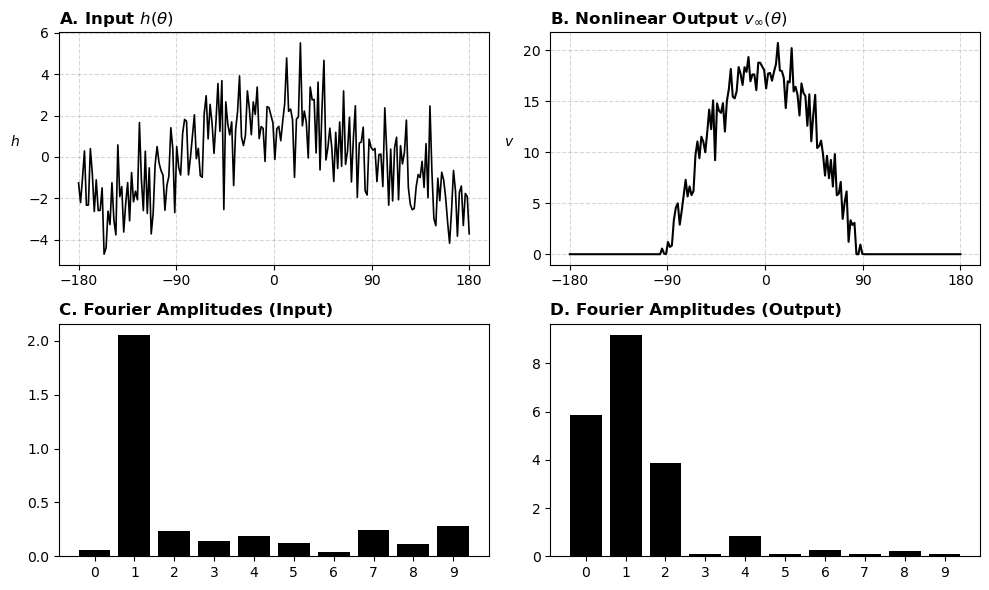

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 初始化网络空间与参数
# ==========================================
theta = np.linspace(-180, 180, 200)
theta_rad = np.radians(theta)
dtheta_rad = theta_rad[1] - theta_rad[0]

# ==========================================
# 2. 生成外部输入 h(theta)
# ==========================================
np.random.seed(42)
# 为了配合非线性网络，我们稍微提高基础余弦的振幅，使其能突破阈值
base_cosine = 2.0 * np.cos(theta_rad) 
noise = 1.5 * np.random.randn(200)
h_input = base_cosine + noise

# ==========================================
# 3. 非线性动力学演化 (Euler Method)
# ==========================================
lambda_1 = 1.9
tau = 20.0 # 时间常数 (ms)
dt = 0.5   # 步长 (ms)
steps = 500

v = np.zeros_like(theta_rad) # 初始放电率均为 0

# 模拟网络随时间的动态演化
for step in range(steps):
    # 利用卷积的特性高效计算循环反馈输入 M * v
    # 因为 M 只有余弦成分，积分化简为计算 v 的傅里叶余弦和正弦系数
    v_cos = np.trapezoid(v * np.cos(theta_rad), dx=dtheta_rad) / np.pi
    v_sin = np.trapezoid(v * np.sin(theta_rad), dx=dtheta_rad) / np.pi
    
    # 循环输入
    recurrent_input = lambda_1 * (v_cos * np.cos(theta_rad) + v_sin * np.sin(theta_rad))
    
    # 核心：计算总输入并进行半波整流 (ReLU: np.maximum)
    total_input = h_input + recurrent_input
    firing_rate_target = np.maximum(0, total_input)
    
    # 更新放电率 (ODE)
    dv = -v + firing_rate_target
    v = v + (dt / tau) * dv

# ==========================================
# 4. 傅里叶分析
# ==========================================
mu_values = np.arange(10)
h_amplitudes = np.zeros(10)
v_amplitudes = np.zeros(10)

for mu in mu_values:
    # 输入的傅里叶振幅
    if mu == 0:
        h_cos = np.trapezoid(h_input, dx=dtheta_rad) / (2 * np.pi)
        h_sin = 0
        v_cos = np.trapezoid(v, dx=dtheta_rad) / (2 * np.pi)
        v_sin = 0
    else:
        h_cos = np.trapezoid(h_input * np.cos(mu * theta_rad), dx=dtheta_rad) / np.pi
        h_sin = np.trapezoid(h_input * np.sin(mu * theta_rad), dx=dtheta_rad) / np.pi
        v_cos = np.trapezoid(v * np.cos(mu * theta_rad), dx=dtheta_rad) / np.pi
        v_sin = np.trapezoid(v * np.sin(mu * theta_rad), dx=dtheta_rad) / np.pi
        
    h_amplitudes[mu] = np.sqrt(h_cos**2 + h_sin**2)
    v_amplitudes[mu] = np.sqrt(v_cos**2 + v_sin**2)

# ==========================================
# 5. 绘图 (完美复刻 Figure 7.9)
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
title_fs, label_fs, tick_fs = 12, 10, 9

# A: Input
axs[0, 0].plot(theta, h_input, color='black', linewidth=1.2)
axs[0, 0].set_title('A. Input $h(\\theta)$', loc='left', fontsize=title_fs, fontweight='bold')
axs[0, 0].set_ylabel('$h$', fontsize=label_fs, rotation=0, labelpad=10)
axs[0, 0].set_xticks([-180, -90, 0, 90, 180])
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# B: Output (现在是一个非线性的 Bump!)
axs[0, 1].plot(theta, v, color='black', linewidth=1.5)
axs[0, 1].set_title('B. Nonlinear Output $v_\\infty(\\theta)$', loc='left', fontsize=title_fs, fontweight='bold')
axs[0, 1].set_ylabel('$v$', fontsize=label_fs, rotation=0, labelpad=10)
axs[0, 1].set_xticks([-180, -90, 0, 90, 180])
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

# C & D: Fourier Amplitudes
axs[1, 0].bar(mu_values, h_amplitudes, color='black', width=0.8)
axs[1, 0].set_title('C. Fourier Amplitudes (Input)', loc='left', fontsize=title_fs, fontweight='bold')
axs[1, 0].set_xticks(mu_values)

axs[1, 1].bar(mu_values, v_amplitudes, color='black', width=0.8)
axs[1, 1].set_title('D. Fourier Amplitudes (Output)', loc='left', fontsize=title_fs, fontweight='bold')
axs[1, 1].set_xticks(mu_values)

plt.tight_layout()
plt.show()

### 7.4.2.2 Recurrent Model 1: **Simple Cells** in Primary Visual Cortex

- recall: 
  - 前馈模型: 初级视觉皮层的感受野是 Lateral Geniculate Nucleus(LGN) 的输入总和. ON 和 OFF 交替排列. 
  - 方位调制(orientation tuning) 难以和大脑皮层的解剖结构吻合
  - 存在大量的皮层内连接, 暗示着循环网络的作用
- Ben-Yishai, Bar-Or & Sompolinsky: 循环网络解释方位调制曲线. 动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}v(\theta)}{\mathrm{d}t} = -v(\theta) + \left[h(\theta) + \int_{-\pi/2}^{\pi/2}\frac{\mathrm{d}\theta^{\prime}}{\pi}[-\lambda_{0} + \lambda_{1}\cos{(2(\theta-\theta^{\prime}))}]v(\theta^{\prime})\right]_{+}\end{aligned}$
  - 引入了全局抑制作用 $-\lambda_{0}$
  - 方位角定义为 $\begin{aligned}\theta^{\prime}\in\left[-\frac{\pi}{2},\frac{\pi}{2}\right]\end{aligned}$ 而非 $[-\pi,\pi]$. 因此额外有一个 2 的因子.
  - 偏好角 $\Theta = 0$ 的输入:  $h(\theta) = Ac[1 - \epsilon + \epsilon\cos{(2\theta)}]$
    - $v(\theta) = v(\theta-\Theta)$, 且 $v(-\theta) = v(\theta)$
    - $A$: 整体幅值
    - $c$: 图像对比度(image contrast)
    - $\epsilon$: 调制强度. 研究中将令 $\epsilon\to 0$, 使强方向调制只可能来源于循环网络作用
      - $\epsilon = 0$: 无调制
      - $\epsilon = 0.5$: 和正向输入一致的最大调制(波谷 $1-2\epsilon = 0$)
  - [Example]

    <img src="https://files.seeusercontent.com/2026/05/04/pyB4/20260504214633248.png" width="70%">

    - A: 前馈输入 $c = [80, 40, 20, 10]\%$, 弱输入调制
    - B: 循环网络 $c = [80, 40, 20, 10]\%$,  $\lambda_{0} = 7.3$, $\lambda_{1} = 11$, $A = 40\,\mathrm{Hz}$, $\epsilon=0.1$, 强输出调制
    - C: 调制曲线

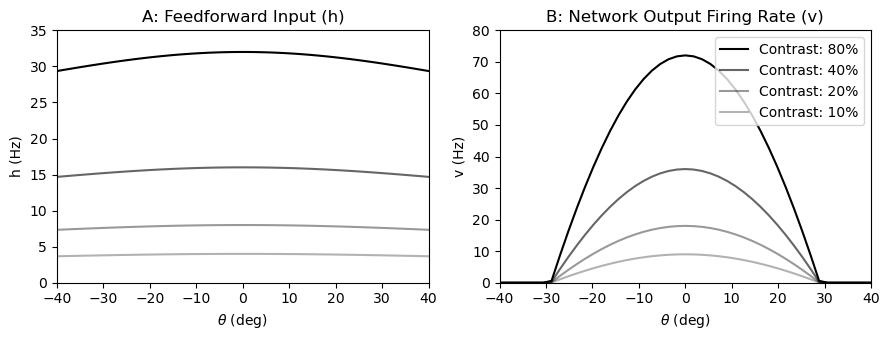

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 参数设置 (根据教材 Figure 7.10 的描述)
# ---------------------------------------------------------
tau_r = 10.0      # 时间常数 (ms)，设定为10ms作为典型值
lambda_0 = 7.3    # 循环抑制强度
lambda_1 = 11.0   # 循环兴奋强度
A = 40.0          # 前馈输入的基础幅度 (Hz)
epsilon = 0.1     # 输入的方位角调制强度
contrasts = [0.8, 0.4, 0.2, 0.1]  # 4个对比度水平: 80%, 40%, 20%, 10%

N = 100           # 神经元的数量 (离散化角度)
theta = np.linspace(-np.pi/2, np.pi/2, N, endpoint=False) # 角度范围从 -90度到90度
d_theta = np.pi / N

# ---------------------------------------------------------
# 2. 构建循环连接权重矩阵 W
# W(theta - theta') = -lambda_0 + lambda_1 * cos(2(theta - theta'))
# ---------------------------------------------------------
W = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        W[i, j] = (-lambda_0 + lambda_1 * np.cos(2 * (theta[i] - theta[j])))

# ---------------------------------------------------------
# 3. 定义仿真函数
# ---------------------------------------------------------
def simulate_network(c, num_steps=500, dt=1.0):
    # 构建前馈输入 h(theta)
    # h(theta) = A * c * (1 - epsilon + epsilon * cos(2 * theta))
    h = A * c * (1 - epsilon + epsilon * np.cos(2 * theta))
    
    # 初始放电率设为0
    v = np.zeros(N)
    
    # 欧拉法数值积分求解常微分方程 (Eq 7.36)
    for _ in range(num_steps):
        # 计算积分项 (矩阵乘法模拟积分)
        recurrent_input = (1.0 / np.pi) * np.dot(W, v) * d_theta
        
        # 计算总驱动力
        total_input = h + recurrent_input
        
        # 经过 ReLU 激活函数 [x]+
        firing_rate_steady = np.maximum(0, total_input)
        
        # 更新 dv/dt
        dv_dt = (-v + firing_rate_steady) / tau_r
        v = v + dv_dt * dt
        
    return h, v

# ---------------------------------------------------------
# 4. 运行仿真并绘图 (复现 Fig 7.10)
# ---------------------------------------------------------
# 缩小 figsize 以避免占用过多篇幅
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# 将弧度转换为角度用于绘图
theta_deg = theta * 180 / np.pi

# 存储结果
h_results = []
v_results = []

for c in contrasts:
    h, v = simulate_network(c=c)
    h_results.append(h)
    v_results.append(v)
    
    # 绘制前馈输入 h(theta)
    ax1.plot(theta_deg, h, label=f'Contrast: {c*100:.0f}%', color='black', alpha=c+0.2)
    # 绘制网络输出 v(theta)
    ax2.plot(theta_deg, v, label=f'Contrast: {c*100:.0f}%', color='black', alpha=c+0.2)

# 图表 A 美化
ax1.set_title('A: Feedforward Input (h)')
ax1.set_xlabel(r'$\theta$ (deg)')  # 使用 r前缀 修复 LaTeX 编译
ax1.set_ylabel('h (Hz)')
ax1.set_xlim([-40, 40])
ax1.set_ylim([0, 35])

# 图表 B 美化
ax2.set_title('B: Network Output Firing Rate (v)')
ax2.set_xlabel(r'$\theta$ (deg)')  # 使用 r前缀 修复 LaTeX 编译
ax2.set_ylabel('v (Hz)')
ax2.set_xlim([-40, 40])
ax2.set_ylim([0, 80])
ax2.legend()

# 使用正确的函数调整子图布局
plt.tight_layout()
plt.show()

### 7.4.2.3 Recurrent Model 2: **Complex Cells** in Primary Visual Cortex

循环网络可以放大选择性响应从而增强选择性, 也可以放大非选择性响应从而减弱选择性. 

recall: 复杂细胞没有 ON/OFF, 而是对特定方位/空间频率光栅做出响应, 而对光栅的位置(空间相位)不敏感

Chance, Nelson & Abbott: 循环网络解释简单细胞响应生成复杂细胞响应. 

- Setup: 
  - $\phi$: 简单细胞偏好的空间相位
  - $h(\phi)$: 模型的前馈输入
  - $\begin{aligned} M(\phi-\phi^{\prime}) = \frac{\lambda_{1}}{2\pi\rho_{\phi}} \end{aligned}$: **均匀** 循环权重
- 动力学: $\begin{aligned} \tau_{r}\frac{\mathrm{d}v(\phi)}{\mathrm{d}t} = - v(\phi) + \left[h(\phi) + \int_{-\pi}^{\pi} \rho_{\phi}\mathrm{d}\phi^{\prime}\,\frac{\lambda_{1}}{2\pi\rho_{\phi}}v(\phi^{\prime}) \right]_{+} \end{aligned}$
  - $\lambda_{1} = 0$: 无循环连接, $v(\phi) = h(\phi)$, 等效于简单细胞 $\phi$
  - $\lambda_{1} \sim 1$: 类似于复杂细胞
- [Example]

    <img src="https://files.seeusercontent.com/2026/05/05/Rec2/20260505155625321.png" width="70%">

  - A: 强调制输入 $\lambda_{1} = 0.95$
  - B: 弱调制输出 (相位不敏感)
  - 并非完全移除了调制差值, 而是通过增强广域的响应使得相对差值变小. 
    - 稳态方程 $\begin{aligned}v_{\infty}(\phi) = h(\phi) + \frac{\lambda_{1}}{2\pi}\int_{-\pi}^{\pi} v(\phi^{\prime})\mathrm{d}\phi^{\prime}\end{aligned}$. 
    - 平均放电率 $\begin{aligned}\bar{v} = \frac{1}{2\pi}\int_{-\pi}^{\pi}v(\phi^{\prime})\mathrm{d}\phi^{\prime}\end{aligned}$, 平均输入 $\begin{aligned}\bar{h} = \frac{1}{2\pi}\int_{-\pi}^{\pi}h(\phi^{\prime})\mathrm{d}\phi^{\prime}\end{aligned}$
    - 稳态方程: $v(\phi) = h(\phi) + \lambda_{1}\bar{v}$. 同时 $\begin{aligned}\int_{-\pi}^{\pi}\mathrm{d}\phi^{\prime}\end{aligned}$, 得到 $\bar{v} = \bar{h} + \lambda_{1}\bar{v}$, 即 $\begin{aligned}\bar{v} = \frac{\bar{h}}{1 - \lambda_{1}}\end{aligned}$
    - $\begin{aligned}v(\phi) = h(\phi) + \frac{\lambda_{1}}{1-\lambda_{1}}\bar{h}\end{aligned}$
    - 绝对差值不变: $\Delta v = \Delta h$
    - 相对差值减小: $\begin{aligned}\frac{\Delta v}{\bar{v}} = \frac{\Delta h}{\bar{h}}\frac{1}{1-\lambda_{1}} = (1-\lambda_{1})\frac{\Delta h}{\bar{h}}\ll \frac{\Delta h}{\bar{h}}\end{aligned}$

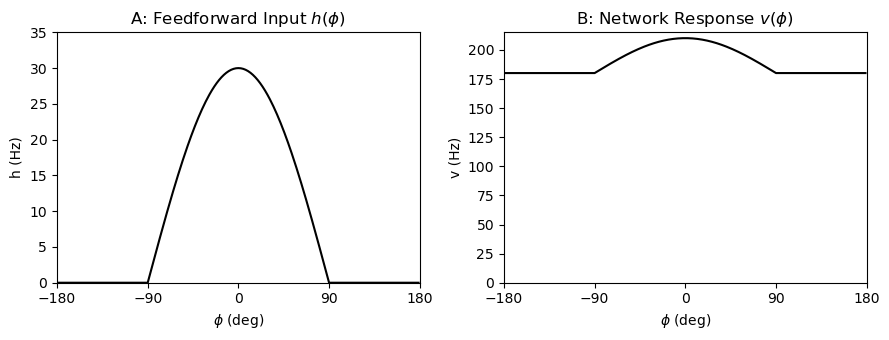

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 参数设置 (复现 Fig 7.11)
# ---------------------------------------------------------
tau_r = 10.0      
lambda_1 = 0.95   # 接近1的全局兴奋系数
N = 300           
phi = np.linspace(-np.pi, np.pi, N, endpoint=False) # 空间相位从 -180 到 180 度
d_phi = 2 * np.pi / N

# ---------------------------------------------------------
# 2. 构建输入 h(phi) (模拟图 7.11A 的简单细胞响应)
# 构造一个带有基线的钟形曲线
# 这里我们用半波整流的余弦函数来近似简单细胞的调谐，并调整振幅使其最大值为30
# ---------------------------------------------------------
h = 30.0 * np.maximum(0, np.cos(phi)) 

# ---------------------------------------------------------
# 3. 运行网络动力学仿真 (Eq 7.38)
# ---------------------------------------------------------
v = np.zeros(N)
dt = 1.0
num_steps = 1000

for _ in range(num_steps):
    # 计算积分项：均匀连接，相当于对整个 v(phi') 求和后再乘以 lambda_1 / (2*pi)
    # \int v(\phi') d\phi' \approx sum(v) * d_phi
    recurrent_input = (lambda_1 / (2 * np.pi)) * np.sum(v) * d_phi
    
    # 总输入
    total_input = h + recurrent_input
    
    # ReLU 激活 [ ]+
    firing_rate_steady = np.maximum(0, total_input)
    
    # 更新状态
    dv_dt = (-v + firing_rate_steady) / tau_r
    v = v + dv_dt * dt

# ---------------------------------------------------------
# 4. 绘图展示
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

phi_deg = phi * 180 / np.pi

# 图 A: 前馈输入
ax1.plot(phi_deg, h, color='black')
ax1.set_title(r'A: Feedforward Input $h(\phi)$')
ax1.set_xlabel(r'$\phi$ (deg)')
ax1.set_ylabel('h (Hz)')
ax1.set_xlim([-180, 180])
ax1.set_ylim([0, 35])
ax1.set_xticks([-180, -90, 0, 90, 180])

# 图 B: 网络稳态输出
ax2.plot(phi_deg, v, color='black')
ax2.set_title(r'B: Network Response $v(\phi)$')
ax2.set_xlabel(r'$\phi$ (deg)')
ax2.set_ylabel('v (Hz)')
ax2.set_xlim([-180, 180])
margin = 5
ax2.set_ylim([0, np.max(v) + margin])
ax2.set_xticks([-180, -90, 0, 90, 180])

plt.tight_layout()
plt.show()

### 7.4.2.4 Winner-Takes-All Input Selection("赢家通吃" 输入选择性)

- 线性网络: 响应线性叠加
- 非线性网络: 多个峰输入, 根据网络选择其中一个峰的响应作为主要输出
  - 不一定幅值越高越好, 需要根据网络权重来确定
  - [Example]

    <img src="https://files.seeusercontent.com/2026/05/05/7xoQ/20260505163203254.png" width="70%">
    
    - Setup: 
    - A: 双峰输入 $h(\phi)$
    - B: 单峰输出 $v(\phi)$

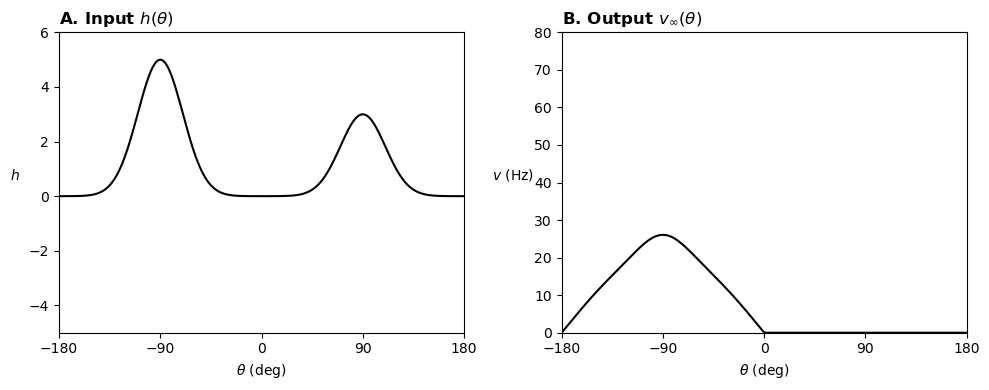

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 初始化网络空间与参数
# ==========================================
theta = np.linspace(-180, 180, 200)
theta_rad = np.radians(theta)
dtheta_rad = theta_rad[1] - theta_rad[0]

# ==========================================
# 2. 生成多峰外部输入 h(theta)
# 构造两个峰值，分别在 -90度和 +90度。
# 按照图 7.12A，-90度的峰稍微高一些。这里我们用高斯函数来构造。
# ==========================================
# 峰 1: 位于 -90 度，振幅约 5.0
peak1 = 5.0 * np.exp(-0.5 * ((theta + 90) / 20.0)**2)
# 峰 2: 位于 +90 度，振幅约 3.0
peak2 = 3.0 * np.exp(-0.5 * ((theta - 90) / 20.0)**2)

h_input = peak1 + peak2

# ==========================================
# 3. 非线性动力学演化 (Euler Method)
# ==========================================
lambda_1 = 1.9
tau = 20.0 # 时间常数 (ms)
dt = 0.5   # 步长 (ms)
steps = 500

v = np.zeros_like(theta_rad) # 初始放电率均为 0

# 模拟网络随时间的动态演化
for step in range(steps):
    # 计算傅里叶级数的投影，这代表了余弦权重的全连接网络
    v_cos = np.trapezoid(v * np.cos(theta_rad), dx=dtheta_rad) / np.pi
    v_sin = np.trapezoid(v * np.sin(theta_rad), dx=dtheta_rad) / np.pi
    
    # 循环输入
    recurrent_input = lambda_1 * (v_cos * np.cos(theta_rad) + v_sin * np.sin(theta_rad))
    
    # 核心：计算总输入并进行半波整流 (引入非线性竞争)
    total_input = h_input + recurrent_input
    firing_rate_target = np.maximum(0, total_input)
    
    # 更新放电率 (ODE)
    dv = -v + firing_rate_target
    v = v + (dt / tau) * dv

# ==========================================
# 4. 绘图 (复刻 Figure 7.12)
# ==========================================
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
title_fs, label_fs = 12, 10

# A: 双峰输入
axs[0].plot(theta, h_input, color='black', linewidth=1.5)
axs[0].set_title('A. Input $h(\\theta)$', loc='left', fontsize=title_fs, fontweight='bold')
axs[0].set_xlabel(r'$\theta$ (deg)', fontsize=label_fs)
axs[0].set_ylabel('$h$', fontsize=label_fs, rotation=0, labelpad=10)
axs[0].set_xlim([-180, 180])
axs[0].set_ylim([-5, 6])
axs[0].set_xticks([-180, -90, 0, 90, 180])

# B: 单峰输出 (赢者通吃结果)
axs[1].plot(theta, v, color='black', linewidth=1.5)
axs[1].set_title('B. Output $v_\\infty(\\theta)$', loc='left', fontsize=title_fs, fontweight='bold')
axs[1].set_xlabel(r'$\theta$ (deg)', fontsize=label_fs)
axs[1].set_ylabel('$v$ (Hz)', fontsize=label_fs, rotation=0, labelpad=15)
axs[1].set_xlim([-180, 180])
axs[1].set_ylim([0, 80])
axs[1].set_xticks([-180, -90, 0, 90, 180])

plt.tight_layout()
plt.show()

### 7.4.2.5 Gain Modulation(增益调节)

recall: 后顶叶神经元(posterior parietal neurons) 依赖于 $s+g$. 

<img src="https://files.seeusercontent.com/2026/04/30/0gMw/20260430150704898.png" width="50%">

- $s$: 视网膜的偏好刺激位置, 也用 $\theta$ 表示
- $g$: 注视方向

<img src="https://files.seeusercontent.com/2026/04/30/aGz0/20260430164409174.png" width="50%">

---

- 动力学: $\begin{aligned}\tau\frac{\mathrm{d}v}{\mathrm{d}t} = - v + \left[h(\theta) + \int_{-\pi}^{\pi}W(\theta,\theta^{\prime})v(\theta^{\prime})\mathrm{d}\theta^{\prime}\right]_{+}\end{aligned}$
  - 输入 $\begin{aligned}h(\theta) = A e^{-\frac{\theta^{2}}{2\sigma^{2}}} + c\end{aligned}$
  - 循环权重 $\begin{aligned}W(\theta,\theta^{\prime}) = \frac{1}{2\pi}[-J_{0} + J_{1}\cos{(\theta - \theta^{\prime})}]\end{aligned}$

<img src="https://files.seeusercontent.com/2026/05/05/o7Xr/20260505164847499.png" width="50%">

- A: 加上各常数项后的输入 $h(\theta)$. 不同常数代表不同的注视方向 $g$. 
- B: 增益调节后的输出 $v(\theta)$. 
  - 峰曲线被成比例地放大了, 绝对位置没有变化

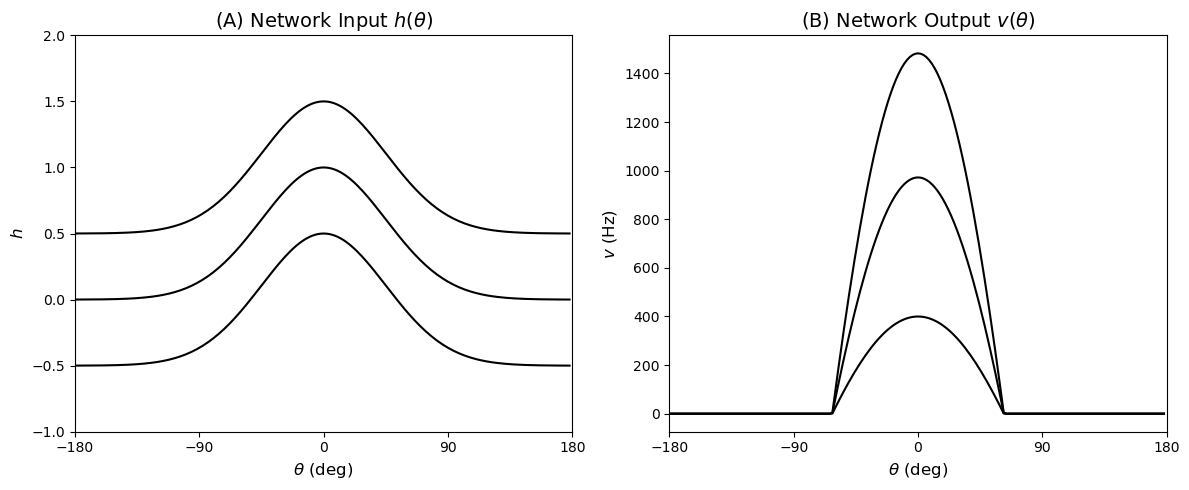

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 修正后的网络参数与物理量 (连续吸引子状态)
# ==========================================
N = 180                     
theta = np.linspace(-180, 180, N, endpoint=False)  
dtheta = 360 / N            
theta_rad = np.deg2rad(theta) 

tau = 10.0                  
dt = 0.5                    
T = 200                     # 稍微延长模拟时间，确保强循环网络达到稳态

# 将网络推入吸引子状态 (Attractor Regime)
J0 = 5.0                    # 增强全局抑制，防止网络兴奋过度爆炸
J1 = 12.0                   # 大幅增强局部兴奋，让循环连接主导形状
W = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        diff = theta_rad[i] - theta_rad[j]
        W[i, j] = (-J0 + J1 * np.cos(diff)) / (2 * np.pi)

def F(x):
    return np.maximum(0, x)

# ==========================================
# 2. 外部输入 h(theta)
# ==========================================
sigma_in = 45.0             # 拓宽外部输入，不再强迫网络变得那么窄
A_in = 1.0                  # 减弱前馈输入的强度，让它仅仅作为"触发器"
h_base = A_in * np.exp(- (theta)**2 / (2 * sigma_in**2))

c_values = [-0.5, 0.0, 0.5] # 缩小加性常数的扰动范围，以防破坏网络稳态

# ==========================================
# 3. 运行网络动力学模拟
# ==========================================
v_steady_states = []        # 存储稳态放电率
h_inputs = []               # 存储对应的总输入

for c in c_values:
    # 构造总输入：视觉峰值 + 注视方向常数
    h = h_base + c
    h_inputs.append(h)
    
    # 初始化网络所有神经元的放电率为 0
    v = np.zeros(N)
    
    # 欧拉法求解微分方程
    for t in np.arange(0, T, dt):
        # 计算所有神经元传来的循环输入 (即积分项 W * v * dtheta)
        recurrent_input = W @ v * np.deg2rad(dtheta)
        
        # 计算放电率的导数 dv/dt
        dv = (-v + F(h + recurrent_input)) / tau
        
        # 更新放电率 v
        v = v + dv * dt
        
    v_steady_states.append(v)

# ==========================================
# 4. 绘图 (复现图 7.13)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 绘制图 A：网络输入 h
for h in h_inputs:
    ax1.plot(theta, h, color='k')
ax1.set_title('(A) Network Input $h(\\theta)$', fontsize=14)
ax1.set_xlabel('$\\theta$ (deg)', fontsize=12)
ax1.set_ylabel('$h$', fontsize=12)
ax1.set_xlim(-180, 180)
ax1.set_ylim(-1, 2)
ax1.set_xticks([-180, -90, 0, 90, 180])

# 绘制图 B：网络输出的稳态放电率 v
for v in v_steady_states:
    ax2.plot(theta, v, color='k')
ax2.set_title('(B) Network Output $v(\\theta)$', fontsize=14)
ax2.set_xlabel('$\\theta$ (deg)', fontsize=12)
ax2.set_ylabel('$v$ (Hz)', fontsize=12)
ax2.set_xlim(-180, 180)
ax2.set_xticks([-180, -90, 0, 90, 180])

plt.tight_layout()
plt.show()

### 7.4.2.6 Sustained Activity(持续活动)

非线性循环网络的循环连接可以产生独立于输入的群体活动. 

- 线性网络 $\begin{aligned} \tau_{r}\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{h} + \mathbb{M}\vec{v} = (\mathbb{M}-\mathbb{I})\vec{v} + \vec{h}\end{aligned}$
  - 具有 $\lambda_{1} = 1$ 的本征矢 $\vec{e}_{1}$. 因此 $\vec{v} = c\vec{e}_{1}\,(\forall c)$ 都是稳态解 (0-mode). 线性网络可记忆 $c$ 值
- 非线性网络
  - 无调制输入时稳态是 $\theta-\Theta$ 的函数(均匀输入带来旋转不变性). 峰值位置 $\Theta$ 相当于被保存. 

- [Example]

    <img src="https://files.seeusercontent.com/2026/05/05/3xmT/20260505192801179.png" width="50%">
    
  - A, C: 输入 $\begin{aligned}\vec{h}(t) = \begin{cases} g(t)\neq 0, t\in (0,t_{0})\\ \mathrm{const}., t\in(t_{0},\infty) \end{cases}\end{aligned}$.
  - B: 对 A 输入的响应
  - D: 在 A 输入撤去转为 C 输入后, 网络的响应
    - 即使表现出了幅值的衰弱, 但是 $\Theta$ 被保留下来
    - *由于稳态旋转不变性, 因此 $\Theta$ 会因为噪音出现漂移现象. 

- 生理学基础
  - 大鼠: 头朝向(head-direction system)
  - 前额叶皮层(prefrontal cortex): 工作记忆任务

**省流: $\begin{aligned}D^{\prime} \propto \frac{D}{N}\end{aligned}$, 故网络越大越抗噪声.** 

1. 动力学: $\begin{aligned} \tau\frac{\partial r(\theta, t)}{\partial t} = - r(\theta, t) + f\left(\int_{-\pi}^{\pi} W(\theta-\theta^{\prime})r(\theta^{\prime}, t)\mathrm{d}\theta^{\prime} + I_{\mathrm{bg}}\right)\end{aligned}$

    无调制输入(仅 $I_{\mathrm{bg}}$): 稳态解 $\begin{aligned}\left(\frac{\mathrm{d}}{\mathrm{d}t}=0\right)\end{aligned}$ : $\begin{aligned}r_{0}(\theta-\Theta) = f(h_{0}(\theta)) = f\left(\int_{-\pi}^{\pi}W(\theta-\theta^{\prime})r_{0}(\theta^{\prime}-\Theta)\mathrm{d}\theta^{\prime} + I_{\mathrm{bg}}\right)\end{aligned}$. 

    引入微扰 $\delta r(\theta, t)$, 则动力学 $\begin{aligned}\tau\frac{\partial (r_{0}+\delta r)}{\partial t} =  - (r_{0} + \delta r) + f(h_{0} + \delta h)=  - (r_{0} + \delta r) + f\left(\int_{-\pi}^{\pi} W(\theta-\theta^{\prime})(r_{0}+\delta r)\mathrm{d}\theta^{\prime} + I_{\mathrm{bg}}\right)\end{aligned}$

    注意 $\begin{aligned}\frac{\partial r_{0}}{\partial t} = 0\end{aligned}$. 采用 Taylor 展开 $f(h_{0}+\delta h)\approx f(h_{0}) + f^{\prime}(h_{0})\delta h$, 有 $\begin{aligned}\tau\frac{\partial \delta r}{\partial t} = -r_{0} - \delta r + f(h_{0}) + f^{\prime}(h_{0})\int_{-\pi}^{\pi}W(\theta-\theta^{\prime})\delta r(\theta^{\prime})\mathrm{d}\theta^{\prime} \end{aligned}$

    注意 $-r_{0} + f(h_{0}) = 0$, 得到微扰动力学 $\begin{aligned}\tau\frac{\partial\delta r}{\partial t} = -\delta r + f^{\prime}(h_{0}(\theta))\int_{-\pi}^{\pi}W(\theta-\theta^{\prime})\delta r(\theta^{\prime})\mathrm{d}\theta^{\prime} = \mathcal{L}\delta r\end{aligned}$

    网络动力学两边对 $\theta$ 求导: $\begin{aligned}r_{0}^{\prime}(\theta-\Theta) = f^{\prime}(h_{0}(\theta))\int_{-\pi}^{\pi}W(\theta-\theta^{\prime})r_{0}^{\prime}(\theta^{\prime}-\Theta)\mathrm{d}\theta^{\prime}\end{aligned}$. 注意 $\delta r = r_{0}^{\prime}$ 时, 有 $\mathcal{L}r_{0}^{\prime} = 0r_{0}^{\prime}$. 
    
    即 $r_{0}^{\prime}$ 是 $\mathcal{L}$ 的 0-mode(特征值为 0). 这代表着网络活动的平移不变性. 

2. 引入噪声 $\langle\xi(\theta, t)\rangle = 0$, $\langle\xi(\theta, t)\xi(\theta^{\prime},t^{\prime})\rangle = 2D\delta(\theta-\theta^{\prime})\delta(t-t^{\prime})$. 

    动力学(Langevin): $\begin{aligned}\tau\frac{\partial r(\theta, t)}{\partial t} = -r(\theta, t) + f\left(\int_{-\pi}^{\pi} W(\theta-\theta^{\prime})r(\theta^{\prime}, t)\mathrm{d}\theta^{\prime} + I_{\mathrm{bg}}\right) + \xi(\theta, t)\end{aligned}$

    写作微扰形式 $r(\theta, t) = r_{0}(\theta-\Theta) + \delta r(\theta, t)$. 链式法则 $\begin{aligned}\frac{\partial r_{0}}{\partial t} = -r_{0}^{\prime}\dot{\Theta}\end{aligned}$, 代入动力学: $\begin{aligned}-\tau\dot{\Theta}r_{0}^{\prime}(\theta-\Theta) + \tau\frac{\partial\delta r}{\delta t} = \mathcal{L}\delta r + \xi(\theta, t)\end{aligned}$

    引入伴随算子 $\mathcal{L}^{\dagger}$, 及其 0-mode $\mathcal{L}^{\dagger}v_{0}^{*} = 0$. 微扰动力学同左乘 $v_{0}^{*}$ 并对 $\theta$ 积分, 且注意 $\begin{aligned}\int v_{0}^{*}(\mathcal{L}\delta r)\mathrm{d}\theta = \int (\mathcal{L}^{\dagger}v_{0}^{*})\delta r\mathrm{d}\theta = 0\end{aligned}$, 则得到 $\begin{aligned} -\tau\dot{\Theta}\int_{-\pi}^{\pi} v_{0}^{*}(\theta^{\prime})r_{0}^{\prime}(\theta^{\prime})\mathrm{d}\theta^{\prime} = \int_{-\pi}^{\pi} v_{0}^{*}(\theta^{\prime}-\Theta)\xi(\theta^{\prime}, t)\mathrm{d}\theta^{\prime} \end{aligned}$, 分离系数: 

    $$
    \begin{equation*}
    \tau\dot{\Theta} = - \frac{\begin{aligned}
        \int_{-\pi}^{\pi} v_{0}^{*}(\theta^{\prime})\xi(\theta^{\prime}, t)\mathrm{d}\theta^{\prime}
    \end{aligned}}{\begin{aligned}
        \int_{-\pi}^{\pi} v_{0}^{*}(\theta^{\prime})r_{0}^{\prime}(\theta^{\prime})\mathrm{d}\theta^{\prime}
    \end{aligned}} = - \frac{\langle v_{0}^{*},\xi\rangle}{\langle v_{0}^{*}, r_{0}^{\prime}\rangle}
    \end{equation*}
    $$

3. 求解扩散系数. 

    $$
    \begin{align*}
    \langle \dot{\Theta}(t^{\prime})\dot{\Theta}(t^{\prime\prime})\rangle &= \frac{1}{\tau^{2}}\frac{\begin{aligned}
        \int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime\prime}\, v_{0}^{*}(\theta^{\prime})v_{0}^{*}(\theta^{\prime\prime})\langle\xi(\theta^{\prime},t^{\prime})\xi(\theta^{\prime\prime}, t^{\prime\prime})\rangle
    \end{aligned}}{\begin{aligned}
        \left[\int_{-\pi}^{\pi}v_{0}^{*}(\theta^{\prime})r_{0}^{\prime}(\theta^{\prime})\mathrm{d}\theta^{\prime}\right]^{2}
    \end{aligned}} = \delta(t^{\prime}-t^{\prime\prime})\frac{1}{\tau^{2}}\frac{\begin{aligned}
        2D\int_{-\pi}^{\pi}[v_{0}^{*}(\theta^{\prime})]^{2}\mathrm{d}\theta^{\prime}
    \end{aligned}}{\begin{aligned}
        \left[\int_{-\pi}^{\pi}v_{0}^{*}(\theta^{\prime})r_{0}^{\prime}(\theta^{\prime})\mathrm{d}\theta^{\prime}\right]^{2}
    \end{aligned}} = 2\,D\frac{\langle v_{0}^{*}, v_{0}^{*}\rangle}{\tau^{2}\langle v_{0}^{*},r_{0}^{\prime}\rangle^{2}}\,\delta(t^{\prime}-t^{\prime\prime})\\
    \langle (\Delta\Theta)^{2}\rangle &= \int_{0}^{t}\mathrm{d}t^{\prime}\int_{0}^{t}\mathrm{d}t^{\prime\prime}\,\langle\dot{\Theta}(t^{\prime})\dot{\Theta}(t^{\prime\prime})\rangle = 2\,\frac{D\langle v_{0}^{*}, v_{0}^{*}\rangle}{\tau^{2}\langle v_{0}^{*},r_{0}^{\prime}\rangle^{2}}\,t = 2\frac{D_{\mathrm{eff}}}{\tau^{2}}t \Rightarrow D_{\mathrm{eff}} = \frac{D\langle v_{0}^{*}, v_{0}^{*}\rangle}{\langle v_{0}^{*},r_{0}^{\prime}\rangle^{2}} = \frac{D}{N_{\mathrm{eff}}}
    \end{align*}
    $$

    定义等效神经元数量 $\begin{aligned}N_{\mathrm{eff}} = \frac{\langle v_{0}^{*},r_{0}^{\prime}\rangle^{2}}{\langle v_{0}^{*}, v_{0}^{*}\rangle}\end{aligned}$ ($\begin{aligned}\langle\cdot,\cdot\rangle_{d} = \frac{N}{2\pi}\langle\cdot,\cdot\rangle_{c}\end{aligned}$ 连续(c)转为离散(d)形式能更好地看出这一点). 

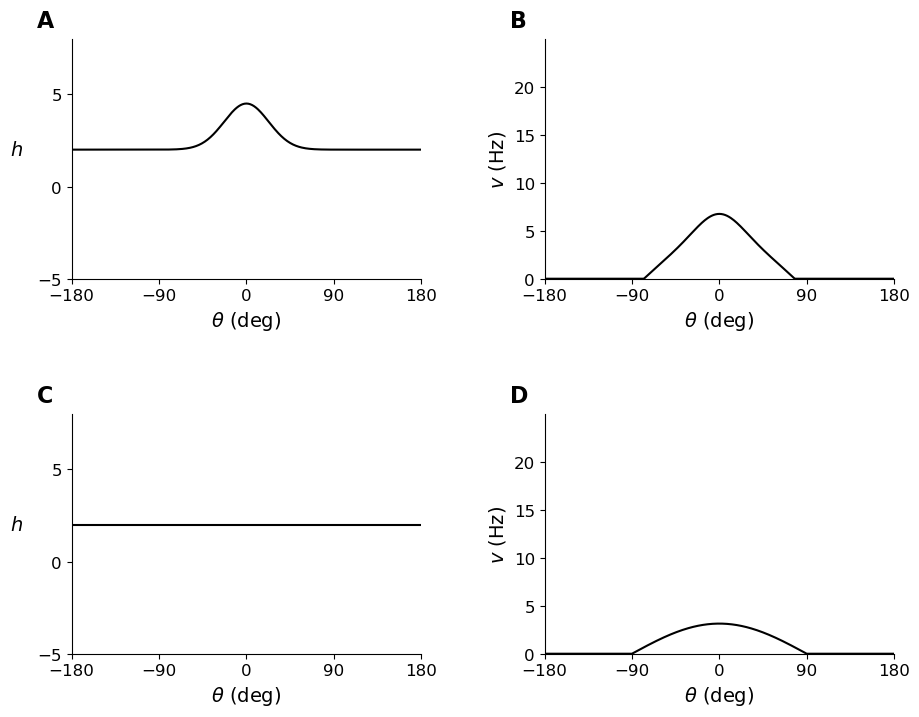

In [6]:
# 非线性网络
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 模型与网络参数设置
# ==========================================
N = 360                      # 神经元数量
theta = np.linspace(-180, 180, N, endpoint=False) # 角度 (-180 到 180度)
theta_rad = np.deg2rad(theta) # 转换为弧度用于计算

tau = 10.0                   # 神经元时间常数 (ms)
dt = 0.5                     # 时间步长 (ms)

# 突触连接矩阵 W (平移不变性: 只依赖于角度差)
# 使用余弦形式: 局部兴奋 (J1 > 0) + 广泛抑制 (J0 < 0)
J0 = -2.0
J1 = 4.0
W = np.zeros((N, N))
for i in range(N):
    W[i, :] = J0 + J1 * np.cos(theta_rad[i] - theta_rad)
W = W / N  # 归一化

# 激活函数: 带有阈值的线性函数 (ReLU)
def f_rect(x):
    return np.maximum(0, x)

# ==========================================
# 2. 模拟网络动力学
# ==========================================

# --- 阶段 1: 带有局部峰值的输入 (对应 Panel A 和 B) ---
# 输入 h = 恒定背景 + 高斯局部刺激
h_A = 2.0 + 2.5 * np.exp(-0.5 * (theta_rad / 0.4)**2)

v = np.zeros(N) # 初始活动为 0
# 运行一段时间到达稳态
for _ in range(int(200 / dt)): 
    total_input = h_A + W @ v
    dv = (-v + f_rect(total_input)) / tau * dt
    v += dv
v_B = v.copy()  # 记录阶段 1 的稳态活动

# --- 阶段 2: 撤销局部刺激，变为完全平坦的恒定输入 (对应 Panel C 和 D) ---
# 输入 h = 恒定背景
h_C = np.full(N, 2.0)

# 从 v_B 的状态继续模拟
for _ in range(int(300 / dt)): 
    total_input = h_C + W @ v
    dv = (-v + f_rect(total_input)) / tau * dt
    v += dv
v_D = v.copy()  # 记录阶段 2 的稳态活动 (工作记忆)


# ==========================================
# 3. 绘制结果 (严格按照原书图 7.14 的排版)
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
plt.rcParams['font.size'] = 12

# (A) 带有局部峰值的输入
axs[0, 0].plot(theta, h_A, 'k-', linewidth=1.5)
axs[0, 0].set_ylim(-5, 8)
axs[0, 0].set_yticks([-5, 0, 5])
axs[0, 0].set_ylabel(r'$h$', fontsize=14, rotation=0, labelpad=15)
axs[0, 0].text(-0.1, 1.05, 'A', transform=axs[0, 0].transAxes, fontsize=16, fontweight='bold')

# (B) 局部输入导致的稳态网络活动
axs[0, 1].plot(theta, v_B, 'k-', linewidth=1.5)
axs[0, 1].set_ylim(0, 25)
axs[0, 1].set_yticks([0, 5, 10, 15, 20])
axs[0, 1].set_ylabel(r'$v$ (Hz)', fontsize=14)
axs[0, 1].text(-0.1, 1.05, 'B', transform=axs[0, 1].transAxes, fontsize=16, fontweight='bold')

# (C) 恒定的平坦输入
axs[1, 0].plot(theta, h_C, 'k-', linewidth=1.5)
axs[1, 0].set_ylim(-5, 8)
axs[1, 0].set_yticks([-5, 0, 5])
axs[1, 0].set_ylabel(r'$h$', fontsize=14, rotation=0, labelpad=15)
axs[1, 0].text(-0.1, 1.05, 'C', transform=axs[1, 0].transAxes, fontsize=16, fontweight='bold')

# (D) 恒定输入下维持的网络活动 (记忆)
axs[1, 1].plot(theta, v_D, 'k-', linewidth=1.5)
axs[1, 1].set_ylim(0, 25)
axs[1, 1].set_yticks([0, 5, 10, 15, 20])
axs[1, 1].set_ylabel(r'$v$ (Hz)', fontsize=14)
axs[1, 1].text(-0.1, 1.05, 'D', transform=axs[1, 1].transAxes, fontsize=16, fontweight='bold')

# 统一设置 X 轴
for ax in axs.flat:
    ax.set_xlim(-180, 180)
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xlabel(r'$\theta$ (deg)', fontsize=14)
    # 去除顶部和右侧的边框线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()

### 7.4.2.7 Maximum Likelihood & Network Recoding(最大似然性, 网络重编码)

- recall: Maximum Likelihood Decoding
  - $N$ 个神经元调制曲线 $f_{i}(s)$ 已知
  - 在时间 $t\in [0, T]$ 观察到 $N$ 个神经元放电活动 $\vec{r} = (r_{1}, r_{2}, \cdots, r_{N})$
  - 由于噪声, 神经元放电概率为 Poisson 分布, 则给定刺激 $s$, 观察到 $\vec{r}$ 的概率为 $\begin{aligned}P(\vec{r}|s) = \prod_{i=1}^{N}\frac{[f_{i}(s)T]^{r_{i}}}{r_{i}!}e^{-f_{i}(s)T} \end{aligned}$
  - 寻找 $s = \hat{s}$ 使得 $P(\vec{r}|s)$ 最大. 对数导数 $\begin{aligned}\frac{\partial \ln{P(\vec{r}|s)}}{\partial s} = \sum_{i=1}^{N}\left[\frac{r_{i}}{f_{i}(s)}f^{\prime}_{i}(s)-f_{i}^{\prime}(s)T\right] = 0\end{aligned}$. 
  - 假设 $f$ 均匀覆盖 $s$ 空间, 则总平均响应约为常数: $\begin{aligned}\sum_{i=1}^{N}f_{i}(s) = \mathrm{const.}\Rightarrow \sum_{i=1}^{N}f_{i}^{\prime}(s) = 0\end{aligned}$. 
  - 解得 $\hat{s}$ 约束为 $\begin{aligned}\sum_{i=1}^{N}r_{i}\frac{f_{i}^{\prime}(s)}{f_{i}(s)} = 0\end{aligned}$
- 循环网络: 大脑不需要计算导数, 而是利用网络结构特性做到同样的效果
  - 循环网络接收复杂输入 $h(\theta)$ 时, 也可产生特征性输出/响应 $v(\theta)$
  - 已知: $h(\theta)$ 改为均匀输入时, 之前的 $v(\theta)$ 的峰值位置 $\Theta$ 仍然维持
  - 特征性输出 $v(\theta)$ 的峰值位置 $\Theta$ 是对输入 $h(\theta)$ 的匹配结果, 可被解读为一种 Maximum Likelihood 解码. 
  - [Example]

    <img src="https://files.seeusercontent.com/2026/05/06/bf8B/20260506140335162.png" width="50%">

    - A: $N = 64$. $h(\theta)$ 噪声标准差 $\sigma = 0.25\,\mathrm{Hz}$. 向量解码输入 $h(\theta)$ 的标准差 $\sigma_{\Theta} = 4.5^{\circ}$. 稳态后均匀输入 $h(\theta) = 10$
    - B: 循环权重为 Gabor-like 函数 $\begin{aligned}W(\theta,\theta^{\prime}) = A\exp{\left[-\frac{(\theta-\theta^{\prime})^{2}}{2\sigma^{2}}\right]}\cos{[k(\theta-\theta^{\prime})]} - B\end{aligned}$. 使用向量解码输出 $v(\theta)$ 得到得 $\sigma_{\Theta} = 1.7^{\circ} \sim 0.88^{\circ}$, 接近 Cramer-Rao 下界.  

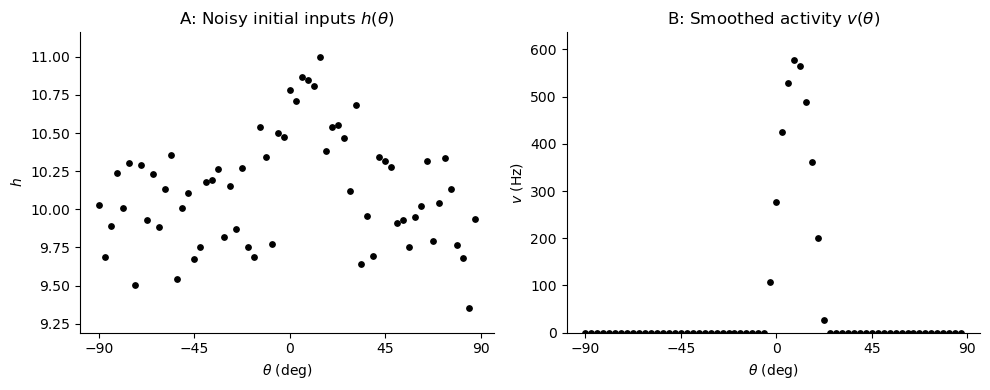

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 网络与仿真参数设置
# ==========================================
N = 64                          # 神经元数量
theta = np.linspace(-90, 90, N, endpoint=False) # 偏好角度空间 [-90, 90)
tau = 10.0                      # 神经元时间常数 (ms)
dt = 1.0                        # 欧拉法仿真步长 (ms)
T_total = 400                   # 总仿真时长 (ms)
time_steps = int(T_total / dt)

# ==========================================
# 2. 构建 Gabor-like 循环权重矩阵 W
# ==========================================
def angle_diff(t1, t2):
    """计算环形空间中的最短角度差 [-90, 90)"""
    diff = t1 - t2
    return (diff + 90) % 180 - 90

A = 1.2            # 兴奋强度
sigma_w = 15.0     # 兴奋扩散范围 (度)
k = np.pi / 45.0   # 空间频率 (控制长程抑制的出现点)
B = 0.5            # 全局抑制

W = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        d_theta = angle_diff(theta[i], theta[j])
        W[i, j] = A * np.exp(-(d_theta**2) / (2 * sigma_w**2)) * np.cos(k * d_theta) - B

# 缩放权重以确保网络动力学稳定
W = W / N * 20.0 

# ==========================================
# 3. 构建输入信号 h(theta, t)
# ==========================================
true_theta = 10.0      # 真实的刺激角度
h_baseline = 10.0      # 恒定的基线输入
signal_strength = 1.0  # 微弱的真实信号隆起
noise_std = 0.25       # 高频噪声的标准差

h = np.zeros((N, time_steps))

# 阶段 1 (0-100ms)：带噪初始输入
initial_signal = h_baseline + signal_strength * np.exp(-(angle_diff(theta, true_theta)**2) / (2 * 10.0**2))
for t in range(int(100 / dt)):
    h[:, t] = initial_signal + np.random.normal(0, noise_std, N)

# 阶段 2 (100ms 之后)：恒定基线输入 (维持吸引子)
for t in range(int(100 / dt), time_steps):
    h[:, t] = h_baseline

# ==========================================
# 4. 运行网络动力学仿真
# ==========================================
v = np.zeros((N, time_steps))

def relu(x):
    return np.maximum(0, x)

# 欧拉法积分
for t in range(time_steps - 1):
    synaptic_input = np.dot(W, v[:, t])
    dv = (-v[:, t] + relu(synaptic_input + h[:, t])) / tau
    v[:, t+1] = v[:, t] + dv * dt

# ==========================================
# 5. 结果可视化 (动态自适应 Y 轴)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

# 图 A: 带噪初始输入 (取第 50 步的快照)
ax1.scatter(theta, h[:, 50], color='black', s=15)
ax1.set_title('A: Noisy initial inputs $h(\\theta)$')
ax1.set_xlabel('$\\theta$ (deg)')
ax1.set_ylabel('$h$')

# 动态计算图 A 的 Y 轴范围 (留出 5% 的上下边距)
h_min, h_max = np.min(h[:, 50]), np.max(h[:, 50])
h_margin = (h_max - h_min) * 0.1 if h_max > h_min else 1.0
ax1.set_ylim(h_min - h_margin, h_max + h_margin)
ax1.set_xticks([-90, -45, 0, 45, 90])

# 图 B: 重编码后的平滑群体活动
ax2.scatter(theta, v[:, -1], color='black', s=15)
ax2.set_title('B: Smoothed activity $v(\\theta)$')
ax2.set_xlabel('$\\theta$ (deg)')
ax2.set_ylabel('$v$ (Hz)')

# 动态计算图 B 的 Y 轴范围 (从 0 开始，顶部留出 10% 的空间展示峰值)
v_max = np.max(v[:, -1])
# 防止初始状态全为 0 导致 ylim(0, 0) 报错
v_ymax = v_max * 1.1 if v_max > 0 else 1.0 
ax2.set_ylim(0, v_ymax)
ax2.set_xticks([-90, -45, 0, 45, 90])

# 去除顶部和右侧的边框以模仿原书排版风格
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 7.4.3 Network Stability(网络稳定性)

不动点行为(fixed-point behavior): 网络对恒定输入 $h(t) = h$ 弛豫到稳态 $\begin{aligned}\left(\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = 0\right)\end{aligned}$

> recall: $\begin{aligned} \tau_{s}\frac{\mathrm{d}I_{s}}{\mathrm{d}t} = - I_{s} + \vec{w}\cdot\vec{u},\quad v = F(I_{s}) \end{aligned}$

延拓至循环网络, 有 Firing-rate model 动力学 $\begin{aligned}\tau_{s}\frac{\mathrm{d}\vec{I}}{\mathrm{d}t} = - \vec{I} + \vec{h} + \mathbb{M}\vec{F}(\vec{I})\end{aligned}$, 或分量形式 $\begin{aligned}\tau_{s}\frac{\mathrm{d}I_{a}}{\mathrm{d}t} = - I_{a} + h_{a} + \sum_{a^{\prime}=1}^{N_{v}}M_{aa^{\prime}}F(I_{a^{\prime}})\end{aligned}$. 假定 $F(\cdot)$ 单调递增($F^{\prime}>0$)

Cohen & Grossberg: 循环网络为对称阵时, 定义 Lyapunov 函数 $\begin{aligned}L(\vec{I}) = \sum_{a=1}^{N_{v}}\left[
    \int_{0}^{I_{a}}\mathrm{d}z_{a}\,z_{a}F^{\prime}(z_{a}) 
    - h_{a}F(I_{a}) 
    - \frac{1}{2}\sum_{a^{\prime}=1}^{N_{v}}F(I_{a})M_{aa^{\prime}}F(I_{a^{\prime}})\right]
\end{aligned}$

若 $\begin{aligned}\frac{\mathrm{d}\vec{I}}{\mathrm{d}t} \neq 0\end{aligned}$, 则 $\begin{aligned}\frac{\mathrm{d}\vec{I}}{\mathrm{d}t} < 0\end{aligned}$. 若 $L$ 有下界, 则 $\vec{I}$ 和 $\vec{v}$ 收敛至不动点. 




---

求导数 $\begin{aligned}\frac{\mathrm{d}L}{\mathrm{d}t}\end{aligned}$. 

- 第一项: $\begin{aligned}\frac{\mathrm{d}}{\mathrm{d}t}\int_{0}^{I_{a}}\mathrm{d}z_{a}\,z_{a}F^{\prime}(z_{a}) = I_{a}\,F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\end{aligned}$
- 第二项: $\begin{aligned}\frac{\mathrm{d}}{\mathrm{d}t}[-h_{a}F(I_{a})] = -h_{a}\,F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\end{aligned}$
- 第三项: $\begin{aligned}\frac{\mathrm{d}}{\mathrm{d}t}\left[-\frac{1}{2}\sum_{a^{\prime}=1}^{N_{v}}F(I_{a})M_{aa^{\prime}}F(I_{a^{\prime}})\right] = -\frac{1}{2}\sum_{a^{\prime}=1}^{N_{v}}\left[F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}M_{aa^{\prime}}F(I_{a^{\prime}}) + F(I_{a})M_{aa^{\prime}}F^{\prime}(I_{a^{\prime}})\frac{\mathrm{d}I_{a^{\prime}}}{\mathrm{d}t}\right] = -\sum_{a^{\prime}=1}^{N_{v}}F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\,M_{aa^{\prime}}F(I_{a^{\prime}})\end{aligned}$
- 求和: $\begin{aligned}\frac{\mathrm{d}L}{\mathrm{d}t} = \sum_{a=1}^{N_{v}}F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t} \left[I_{a} - h_{a} - \sum_{a^{\prime}=1}^{N_{v}}M_{aa^{\prime}}F(I_{a^{\prime}})\right]\end{aligned}$, 注意动力学 $\begin{aligned}-\tau_{s}\frac{\mathrm{d}I_{a}}{\mathrm{d}t} = I_{a} - h_{a} - \sum_{a^{\prime}=1}^{N_{v}}M_{aa^{\prime}}F(I_{a^{\prime}})\end{aligned}$, 替换得出结论
- 结论: $\begin{aligned}\frac{\mathrm{d}L}{\mathrm{d}t} = \sum_{a=1}^{N_{v}}F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\left(-\tau_{s}\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\right) = -\tau_{s}\sum_{a=1}^{N_{v}}F^{\prime}(I_{a})\left(\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\right)^2\leq 0\end{aligned}$

---

$F^{\prime} > 0$ 是一个计算方便的假设. 实际上, $F(x) = [x]_{+}$ 也满足不动点条件. (相当于 $I<0$ 的神经元暂时退出网络)





- 更一般的结论: 不动点要求 Lyapunov 函数有下界. 方法:
  - 使用饱和激活函数(saturating activation function, 如 sigmoid 函数): $I\to\infty, \exists\,\mathrm{sup}\,F(I)$
  - $\mathbb{M}$ 的本征值足够小

## 7.4.4 Associative Memory(联想记忆)

- 短期记忆/工作记忆
  - 通过持续活动保存信息
  - 数秒到数分钟级别
- 长期记忆
  - 通过突触强度的存储保存信息
  - 突触权重被修改, 持续活动作为发起回忆的信号, 从而生成特定输出模式(pattern) $\vec{v}$. 突触权重作为所有记忆模式(pattern)的长期存储库
  - 生物学基础
    - 海马体(hippocampus) 的 CA3 区
    - 部分前额叶皮质(prefrontal cortex)
  - 联想记忆: 通过部分输入存储模式, 来回忆完整模式(内容寻址 content-addressable); 不同于计算机的地址寻址(address-addressable)
    - [Example] 314159...
    - 循环权重 $\mathbb{M}$ 被设计, 从而拥有一组离散不动点, 每一个不动点对应记忆模式. 
    - 不动点的吸引域(basin of attraction): 使网络演化到该不动点的活动相空间. 


动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\vec{h} + \mathbb{M}\vec{v})\end{aligned}$, 设 $\vec{h} = 0$. 

要求网络存储 $N_{\mathrm{mem}}$ 个记忆模式 $\vec{v}^{(m)}\,(m=1,2,\ldots,N_{\mathrm{mem}})$, 且初始状态 $\vec{v}(0)\approx \vec{v}^{(m)}$ 演化后收敛至 $\vec{v}^{(m)}$. 不动点方程 $\vec{v}^{(m)} = \vec{F}(\mathbb{M}\vec{v}^{(m)})$

简化: 不活跃神经元 $v^{(m)}_{i} = 0$, 活跃神经元 $v_{i}^{(m)} = c$. 设每个记忆模式有 $\alpha N_{v}$ 个活跃神经元和 $(1-\alpha)N_{v}$ 个不活跃神经元. 

> $\alpha$: 记忆模式的稀疏度(sparsity). $\alpha$ 减小则模式稀疏, 可存储更多模式, 而信息量更少 

构造 $\mathbb{K}$, 记忆模式 $\vec{v}^{(m)}$ 均是其本征矢且本征值相同: $\mathbb{K}\vec{v}^{(m)} = \lambda\vec{v}^{(m)}\,(\forall m)$. 

构造权重矩阵 $\begin{aligned}\mathbb{M} = \mathbb{K} - \frac{\vec{1}\vec{1}^{T}}{\alpha N_{v}}\end{aligned}$, 列向量 $\vec{1} = [1,1,\ldots,1]^{T}\in\mathbb{R}^{N_{v}}$, 第二项代表全局抑制. 

注意 $\begin{aligned}\mathbb{M}\vec{v}^{(m)} = \lambda\vec{v}^{(m)} - \frac{\vec{1}}{\alpha N_{v}}[\vec{1}^{T}\vec{v}^{(m)}] = \lambda\vec{v}^{(m)} - \frac{\vec{1}}{\alpha N_{v}} c\alpha N_{v} = \lambda\vec{v}^{(m)} - c\vec{1}\end{aligned}$. 

相当于活跃神经元输入 $\lambda c-c = (\lambda-1)c$, 不活跃神经元输入 $0-c = -c$. 对应不动点方程组 $c = F[(\lambda-1)c]$ 和 $0 = F(-c)$. 

- $c>0$. 对于 $F(x) = [x]_{+}$
  - $F(-c) = 0$ 恒成立. 
  - 若 $F^{\prime} > 0$, 则 $\lambda > 1$. 可以计算得到临界 $\lambda_{c} = 2$. 稍微偏离 $\lambda_{c}$ 则会发散或者衰减. 
  - 生物学条件: 
    - $\lambda > 1$, 以保证 $c(\lambda-1)>0$
    - $(\lambda-1)F^{\prime}(0) > 1$: 网络迅速逃离 $0$ 状态
    - $F(c(\lambda-1))$ 增长慢于 $c$ (饱和性 saturation), 避免发散



$\vec{v}^{(m)}$ 为矩阵 $\mathbb{K}$ 的 $N_{\mathrm{mem}}$ 度简并本征矢, 因此存在虚假(spurious)不动点 $\begin{aligned}\vec{v}_{s} = \sum_{m=1}^{N_{\mathrm{mem}}} c_{m}\vec{v}^{(m)}\end{aligned}$ 同样满足本征方程 $\mathbb{K}\vec{v}_{s} = \lambda\vec{v}_{s}$. 

网络非线性阻止 $\vec{v}_{s}$ 满足不动点方程 $\vec{v} = \vec{F}(\mathbb{M}\vec{v})$. 

- 设想 $\begin{aligned}\sum_{m=1}^{N_{\mathrm{mem}}}c_{m} = 1\end{aligned}$ 使得输出仍然为 $c$. 
- 然而, 存在非重叠区(如只在模式 1 活跃), 其输入仅为 $c_{1}c$. 而要求饱和响应(非线性), 无法做到 $c_{1}c = F(c_{1}c)$. 
- 因此 $\begin{aligned}\vec{v}_{s} = \sum_{m=1}^{N_{\mathrm{mem}}} c_{m}\vec{v}^{(m)}\end{aligned}$ 不满足不动点方程